In [1]:
import os

# General packages
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import PIL.Image
from tqdm.notebook import tqdm, trange
import glob
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from IPython.display import Image as IImage
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")
tqdm.pandas()

In [2]:
from sentence_transformers import SentenceTransformer, util
embedder = SentenceTransformer('all-MiniLM-L6-v2')


In [3]:
os.listdir('/raid/AISSEL/Hamed/datasets/av_data/fatemeh')

['all', 'missed', 'df_test.pk']

## get topics

In [4]:
from bertopic import BERTopic
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)

In [5]:
lemmatizer = WordNetLemmatizer()

In [8]:
def get_topics(concept='pedestrian'):
    if concept == 'pedestrian':
        model_path = '../ped_auto_model'
    elif concept == 'aircraft':
        model_path = '../aircraft_auto_model'
    elif concept == 'car':
        model_path = '../car_auto_model'
    auto_model = BERTopic(nr_topics="auto")
    auto_model = BERTopic.load(model_path)
    similar_topics, similarity = auto_model.find_topics(concept, top_n=50)

    topics = dict()
    for t in similar_topics:
        l1 = auto_model.get_topic(t)
        el_list = []
        el_list.append(concept)
        for el in l1:
            w = lemmatizer.lemmatize(el[0], get_wordnet_pos(el[0]))
            el_list.append(w)
        topics[t]= set(el_list)
    return topics

In [10]:
auto_model = BERTopic(nr_topics="auto")
auto_model = BERTopic.load('../aircraft_auto_model')

In [11]:
av_similar_topics, av_similarity =auto_model.find_topics("aircraft", top_n=50)
print(av_similar_topics)

[63, 3, 271, 145, 298, 11, 45, 201, 35, 108, 58, 144, 157, 186, 230, 159, 220, 77, 256, 104, 86, 2, 34, 247, 23, 80, 165, 32, 319, 126, 66, 225, 25, 8, 235, 295, 227, 44, 234, 50, 251, 31, 10, 258, 72, 93, 118, 19, 139, 237]


In [12]:
topics = get_topics(concept='aircraft')
q_id = [el for el in topics]

In [13]:
topics = {63: {'aerodynamic',
  'aircraft',
  'airplane',
  'aviation',
  'fly',
  'fuselage',
  'plane',
  'wing'},
 3: {'aircraft',
  'aviation',
  'fighter',
  'flew',
  'flight',
  'fly',
  'lindbergh',
  'pilot',
  'squadron'},
 271: {'aerial',
  'aerodrome',
  'aircraft',
  'airport',
  'airspace',
  'aviation',
  'flight',
  'fly',
  'icao',
  'licensing',
  'pilot'},
 145: {'aeroflot',
  'aeroflots',
  'aerosvit',
  'aircraft',
  'airline',
  'airport',
  'boeing',
  'flight',
  'superjet',
  'volgadnepr'},
 298: {'aircraft',
  'airline',
  'aviation',
  'corporate',
  'openairplane',
  'pilot',
  'remuneration',
  'shareholders13',
  'stakeholder'},
 11: {'airbus',
  'aircraft',
  'airline',
  'airliner',
  'airport',
  'boeing',
  'flight',
  'lufthansa',
  'passenger',
  'southwest'},
 45: {'aircraft',
  'armament',
  'bomber',
  'corsair',
  'fighter',
  'fuselage',
  'navy',
  'squadron',
  'wing'},
 201: {'aerobot',
  'aerobraking',
  'aerodynamic',
  'aeronautics',
  'aircraft',
  'balloon',
  'fly',
  'glide',
  'rocket',
  'spacecraft',
  'spaceflight'},
 35: {'1900d',
  'aircraft',
  'beech',
  'beechcraft',
  'cabin',
  'cessna',
  'engine',
  'gear',
  'skyhawk',
  'wing'},
 108: {'aircraft',
  'biplane',
  'cantilever',
  'design',
  'fuselage',
  'monoplane',
  'sesquiplane',
  'strut',
  'wing'},
 58: {'737',
  '747',
  '747400',
  '747400s',
  '7478',
  'aircraft',
  'airline',
  'airliner',
  'boeing',
  'boeings',
  'freighter'},
 144: {'1943',
  '1944',
  'aircraft',
  'armament',
  'bomber',
  'raf',
  'squadron',
  'v72',
  'vengeance'},
 157: {'aerial',
  'aircraft',
  'balloon',
  'bomber',
  'camera',
  'photographic',
  'photography',
  'reconnaissance'},
 186: {'aircraft',
  'albatros',
  'armament',
  'benz',
  'biplane',
  'diii',
  'fuselage',
  'mercedes',
  'strut',
  'wing'},
 230: {'aircraft',
  'airlift',
  'airlifters',
  'cargo',
  'carry',
  'equipment',
  'helicopter',
  'payload',
  'pylon',
  'transport'},
 159: {'aircraft',
  'beaufort',
  'beauforts',
  'fuselage',
  'pilot',
  'raf',
  'spitfire',
  'squadron',
  'supermarine'},
 220: {'911',
  'aircraft',
  'airline',
  'faa',
  'flight',
  'hijack',
  'hijacker',
  'pentagon',
  'plane',
  'tower'},
 77: {'aircraft',
  'airline',
  'airport',
  'boeing',
  'calgary',
  'fleet',
  'flight',
  'toronto',
  'vancouver',
  'westjet'},
 256: {'aircraft', 'airline', 'airport', 'code', 'digit', 'flight', 'number'},
 104: {'1916',
  'aircraft',
  'argosy',
  'biplane',
  'engine',
  'fighter',
  'fit',
  'fly',
  'raf',
  'wing'},
 86: {'aircraft',
  'airline',
  'airport',
  'airway',
  'boeing',
  'fiji',
  'flight',
  'pacific',
  'qantas',
  'sydney'},
 2: {'aircraft',
  'airline',
  'cockpit',
  'crash',
  'crashed',
  'crew',
  'investigator',
  'passenger',
  'pilot',
  'wreckage'},
 34: {'administration',
  'aircraft',
  'airline',
  'airport',
  'amend',
  'aviation',
  'federal',
  'legislation',
  'tsa'},
 247: {'aircraft',
  'cockpit',
  'control',
  'display',
  'gunner',
  'instrument',
  'panel',
  'pilot'},
 23: {'aircraft',
  'amelia',
  'aviation',
  'flew',
  'flight',
  'fly',
  'pilot',
  'woman'},
 80: {'aerodynamic',
  'aircraft',
  'flight',
  'hypersonic',
  'land',
  'lift',
  'rocket',
  'shuttle',
  'spacecraft',
  'spaceplane'},
 165: {'aircraft',
  'bluebird',
  'bomber',
  'built',
  'design',
  'fuselage',
  'hampdens',
  'patent',
  'prototype',
  'raf',
  'wing'},
 32: {'aircraft',
  'boat',
  'floatplane',
  'flyingboat',
  'naval',
  'seaplane',
  'ship'},
 319: {'aeronautical',
  'aeronautics',
  'aircraft',
  'design',
  'engineer',
  'engineering',
  'hypersonic',
  'ice',
  'langley',
  'pyrodyne',
  'rodert'},
 126: {'aircraft',
  'anxiety',
  'aviophobia',
  'circadian',
  'fatigue',
  'fear',
  'flight',
  'fly',
  'phobia',
  'pilot'},
 66: {'aircraft',
  'airport',
  'airspace',
  'atc',
  'clearance',
  'controller',
  'faa',
  'flight',
  'pilot',
  'radar'},
 225: {'aerospace',
  'airbus',
  'aircraft',
  'boeing',
  'bombardier',
  'company',
  'industry',
  'merger',
  'supplier'},
 25: {'1944',
  'aircraft',
  'bomber',
  'bombing',
  'combat',
  'fighter',
  'luftwaffe',
  'pilot',
  'raf'},
 8: {'aircraft',
  'airfield',
  'airlift',
  'deployed',
  'fly',
  'mission',
  'operational',
  'raf',
  'squadron'},
 235: {'737',
  '737700',
  '737800',
  '737ng',
  '737s',
  'aircraft',
  'airline',
  'boeing',
  'boeings',
  'fuselage',
  'southwest'},
 295: {'airasia',
  'airbus',
  'aircraft',
  'airline',
  'boeing',
  'brunei',
  'kuala',
  'lumpur',
  'malaysia',
  'malaysian'},
 227: {'aircraft',
  'airline',
  'amazon',
  'ati',
  'boeing',
  'cargo',
  'cargolux',
  'charter',
  'fleet'},
 44: {'aircraft',
  'armament',
  'bomber',
  'design',
  'engine',
  'fuselage',
  'ju',
  'luftwaffe',
  'messerschmitt',
  'wing'},
 234: {'1944',
  'aircraft',
  'bomber',
  'havilland',
  'hornet',
  'mosquito',
  'raf',
  'squadron'},
 50: {'aircraft',
  'canadian',
  'dh60',
  'dhc',
  'fly',
  'fuselage',
  'havilland',
  'moth',
  'otter'},
 251: {'aircraft',
  'airliner',
  'company',
  'il214',
  'jet',
  'mig35',
  'su35s',
  'superjet',
  'tu204',
  'uac',
  'uacs'},
 31: {'aerial',
  'aircraft',
  'dji',
  'drone',
  'reconnaissance',
  'sensor',
  'uas',
  'uav',
  'uavs',
  'unmanned'},
 10: {'aircraft',
  'airfield',
  'airline',
  'airport',
  'county',
  'facility',
  'flight',
  'runway'},
 258: {'aircraft',
  'airway',
  'cabin',
  'fairchild',
  'fuselage',
  'h45',
  'h47',
  'husky',
  'monoplane',
  'rcaf'},
 72: {'1910',
  '1942',
  '1942nd',
  'aerospace4',
  'aircraft',
  'aviation',
  'aviationrelated',
  'birmingham',
  'event',
  'huntsville',
  'year'},
 93: {'aeronautical',
  'aeronautics',
  'aerospace',
  'aircraft',
  'aviation',
  'engineer',
  'engineering',
  'flight',
  'mechanical',
  'optimization'},
 118: {'aircraft',
  'airline',
  'airway',
  'bcal',
  'bcals',
  'bua',
  'flight',
  'gatwick',
  'heathrow',
  'london'},
 19: {'aircraft', 'glide', 'glider', 'kite', 'sailplane', 'soar', 'wing'},
 139: {'a37',
  'a37b',
  'aircraft',
  'cessna',
  'navy',
  'refuel',
  't33',
  't37',
  'trainer',
  'training',
  'usaf'},
 237: {'aircraft',
  'captain',
  'copilot',
  'crew',
  'duty',
  'faa',
  'officer',
  'operate',
  'operation',
  'pilot',
  'pilotincommand'}}

In [14]:
for el in topics:
    print(el, topics[el])

63 {'aviation', 'aircraft', 'plane', 'aerodynamic', 'airplane', 'fly', 'wing', 'fuselage'}
3 {'lindbergh', 'aviation', 'flew', 'aircraft', 'pilot', 'squadron', 'fighter', 'fly', 'flight'}
271 {'aviation', 'airspace', 'airport', 'aircraft', 'pilot', 'aerodrome', 'licensing', 'flight', 'fly', 'aerial', 'icao'}
145 {'airport', 'aircraft', 'superjet', 'boeing', 'aerosvit', 'aeroflots', 'aeroflot', 'volgadnepr', 'flight', 'airline'}
298 {'aviation', 'remuneration', 'aircraft', 'pilot', 'shareholders13', 'openairplane', 'corporate', 'stakeholder', 'airline'}
11 {'airport', 'aircraft', 'airbus', 'passenger', 'southwest', 'boeing', 'lufthansa', 'airliner', 'flight', 'airline'}
45 {'bomber', 'aircraft', 'squadron', 'fighter', 'navy', 'wing', 'armament', 'fuselage', 'corsair'}
201 {'spaceflight', 'aeronautics', 'glide', 'aircraft', 'balloon', 'aerodynamic', 'aerobot', 'spacecraft', 'fly', 'rocket', 'aerobraking'}
35 {'engine', 'skyhawk', 'beech', 'aircraft', 'beechcraft', 'cabin', 'cessna', 'win

In [15]:
topics[86]

{'aircraft',
 'airline',
 'airport',
 'airway',
 'boeing',
 'fiji',
 'flight',
 'pacific',
 'qantas',
 'sydney'}

In [16]:
pg_t = dict()
pg_t['a'] = [31]
pg_t['b'] = [19, 32]
pg_t['c'] = [157, 230, 63, 319, 8, 201]
pg_t['d'] = [144, 45, 104, 35, 44, 165, 186]
pg_t['e'] = [8, 25, 159, 108, 50, 234]

pg_t['f'] = [235, 225, 58, 227]
pg_t['g'] = [93, 258, 139, 251]
pg_t['h'] = [145, 256, 34, 11, 77, 86, 10, 118, 295]
pg_t['k'] = [3, 271, 298]
pg_t['i'] = [247, 2, 237, 72, 23, 126, 66, 220]

In [17]:
for el in pg_t:
    group_words = []
    for t in pg_t[el]:
        group_words.extend(list(topics[t]))
#         break
    pg_t[el]= list(set(group_words))
    

In [18]:
print(pg_t[el])

['circadian', 'panel', 'control', 'cockpit', 'crashed', 'airport', 'radar', 'crew', 'crash', 'plane', 'atc', 'hijack', 'phobia', 'woman', '1910', '1942nd', 'birmingham', 'fear', 'faa', 'flight', 'aviationrelated', '1942', 'aircraft', 'fatigue', 'clearance', 'investigator', '911', 'officer', 'airline', 'operation', 'hijacker', 'aviation', 'year', 'aviophobia', 'pilot', 'passenger', 'tower', 'duty', 'event', 'controller', 'captain', 'flew', 'copilot', 'amelia', 'wreckage', 'aerospace4', 'display', 'airspace', 'anxiety', 'gunner', 'operate', 'pilotincommand', 'huntsville', 'fly', 'instrument', 'pentagon']


In [19]:
for g in pg_t:
    pg_t[g] = ' '.join(pg_t[g])

In [20]:
pg_t[g]

'circadian panel control cockpit crashed airport radar crew crash plane atc hijack phobia woman 1910 1942nd birmingham fear faa flight aviationrelated 1942 aircraft fatigue clearance investigator 911 officer airline operation hijacker aviation year aviophobia pilot passenger tower duty event controller captain flew copilot amelia wreckage aerospace4 display airspace anxiety gunner operate pilotincommand huntsville fly instrument pentagon'

In [21]:
toopic_dict = dict()
for el in topics:
    toopic_dict[el] = ' '.join(topics[el])
toopic_dict[el]

'aircraft pilot crew operate pilotincommand duty officer captain faa copilot operation'

## Load Predictions

In [41]:
pd.set_option('display.max_rows', None)

d_path = '/raid/AISSEL/Hamed/datasets/av_data'
# df = pd.read_pickle(f'{d_path}/val_prediction_trained_on_base.pk')
# df = pd.read_pickle(f'{d_path}/val_prediction_trained_on_all.pk')
df = pd.read_pickle(f'{d_path}/val_prediction_trained_on_missed.pk')
df

,uniq_id,image_id,caption,context,topic_id,labels,image,topics,ofa_caption
0,12,12,This drone is an example of UAV that could be ...,Humanrobot interaction is the study of interac...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A drone is a drone that can be flown in the air
1,25,25,Ryan BQM34 Firebee jetpropelled drone used as ...,A target drone is an unmanned aerial vehicle g...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A airplane that was involved in the accident
2,28,28,ARDrone preproduction prototype Parrot ARDrone...,Parrot ARDrone is a discontinued remote contro...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A helicopter in the process of taking off from...
3,63,63,English Naval Aircraft Factory TDN1 assault d...,The Naval Aircraft Factory TDN was an early un...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aircraft in flight at the time of the accident
4,76,76,Unmanned Aerial Vehicle trainer at Holloman Ai...,The 429th Attack Squadron is a classic associa...,31,,iVBORw0KGgoAAAANSUhEUgAABAAAAAKpCAIAAACtvMnIAA...,a,A pilots sit in the cockpit of a flight simulator
5,111,111,ScanEagle reconnaissance UAV on its catapult l...,A reconnaissance aircraft is a military aircra...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aircraft parked in the desert
6,119,119,Eastern Beach Aerial Photo English Drone shot ...,Eastern Beach is a suburb of Auckland New Zeal...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aerial view of bondi beach in sydney
7,137,137,PIK20E finnish glider Used by NASA Dryden Fli...,This is a list of NASA aircraft Throughout its...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,A drone flying in the air
8,159,159,Schweizer SGS 126 onedesign sailplane English ...,OneDesign is a racing method which may be adop...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,The airplane of the same name
9,191,191,Wings of a female Dune Glider Tramea eurybia ...,Tramea eurybia is a species of dragonfly in th...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,Aductor fascia of the femur


In [42]:
aircraft_list = ['aircraft', 'airplane', 'plane', 'fighter', 
                 'boeing', 'superjet', 'airbus', 'bomber', 'glide', 
                 'skyhawk', 'balloon', 'helicopter', 'seaplane', 'jet',
                 'mig35', 'su35s', 'dji', 'drone', 'uas', 'uav', 'glide', 'kite']

In [43]:
d = [None] * 273

In [44]:
d[0] = {'drone': 1, 'reconnaissance':0, 'dji':1, 'uavs':1, 'uas':1, 
      'uav':1, 'aircraft':1, 'aerial':1, 'unmanned':1, 'sensor':0}
d[1] = {'drone': 1, 'reconnaissance':0, 'dji':0, 'uavs':1, 'uas':1, 
      'uav':1, 'aircraft':1, 'aerial':1, 'unmanned':1, 'sensor':0}
d[2] = {'aerial': 1, 'aircraft': 1, 'sensor': 0, 'uav':1, 'uas':1, 
      'uavs':1, 'unmanned':1, 'dji':1, 'reconnaissance':0, 'drone':1}
d[3] = {'aerial': 1 , 'aircraft':1, 'sensor':0, 'uav':0, 'uas': 0, 'uavs':0, 'unmanned':0, 
      'dji':0, 'reconnaissance':0, 'drone':0}
d[4] = {'aerial':0, 'aircraft':1, 'sensor':1, 'uav':0, 'uas':0, 'uavs':0, 
      'unmanned':0, 'dji':0, 'reconnaissance':0, 'drone':0}
d[5] = {'aerial':0, 'aircraft':1, 'sensor':0, 'uav':1, 'uas':1, 'uavs':1,
      'unmanned':1, 'dji':0, 'reconnaissance':0, 'drone':1}
d[6] = {'aerial':1, 'aircraft':0, 'sensor':0, 'uav':0, 'uas':0, 'uavs':0, 
      'unmanned':0, 'dji':0, 'reconnaissance':0, 'drone':0}
d[7] = {'aircraft':1, 'glide':1, 'sailplane':1, 'kite':0, 'glider':0, 'wing':1, 'soar':1}
d[8] = {'aircraft':1, 'glide':0, 'sailplane':0, 'kite':0, 'glider':0, 'wing':1, 'soar':0}
d[9] = {'aircraft':0, 'glide':0, 'sailplane':0, 'kite':0, 'glider':0, 'wing':1, 'soar':0}
d[10] = {'sailplane':0, 'glide':0, 'wing':1, 'kite':0, 'soar':0, 'glider':0, 'aircraft':0}
d[11] = {'sailplane':1, 'glide':1, 'wing':1, 'kite':1, 'soar':0, 'glider':1, 'aircraft':1}
d[12] = {'sailplane':1, 'glide':0, 'wing':1, 'kite':0, 'soar':0, 'glider':0, 'aircraft':1}
d[13] = {'sailplane':1, 'glide':1, 'wing':1, 'kite':0, 'soar':0, 'glider':1, 'aircraft':1}
d[14] = {'naval':1, 'boat':1, 'ship':1, 'flyingboat':0, 'floatplane':0, 
       'aircraft':0, 'seaplane':0}
d[15] = {'naval':1, 'boat':1, 'ship':1, 'flyingboat':0, 
       'floatplane':0, 'aircraft':0, 'seaplane':0}
d[16] = {'naval':1, 'boat':1, 'ship':1, 'flyingboat':0, 
       'floatplane':0, 'aircraft':0, 'seaplane':0}
d[17] = {'naval':1, 'boat':1, 'ship':1, 'flyingboat':0, 
       'floatplane':0, 'aircraft':0, 'seaplane':0}
d[18] = {'naval':1, 'boat':1, 'ship':1, 'flyingboat':0, 
       'floatplane':0, 'aircraft':0, 'seaplane':0}
d[19] = {'naval':1, 'boat':1, 'ship':1, 'flyingboat':0, 
       'floatplane':0, 'aircraft':0, 'seaplane':0}
d[20] = {'photographic':0, 'camera':0, 'reconnaissance':0, 
       'aerial':1, 'bomber':0, 'aircraft':0, 'photography':0, 'balloon':1}
d[21] = {'photographic':0, 'camera':0, 'reconnaissance':0, 
       'aerial':0, 'bomber':0, 'aircraft':1, 'photography':0, 'balloon':0}
d[22] = {'photographic':0, 'camera':0, 'reconnaissance':0, 
       'aerial':0, 'bomber':0, 'aircraft':1, 'photography':0, 'balloon':0}
d[23] = {'photographic':0, 'camera':0, 'reconnaissance':0, 
       'aerial':1, 'bomber':0, 'aircraft':1, 'photography':0, 'balloon':0}
d[24] = {'photographic':0, 'camera':0, 'reconnaissance':0, 
       'aerial':1, 'bomber':0, 'aircraft':1, 'photography':0, 'balloon':0}
d[25] = {'photographic':0, 'camera':0, 'reconnaissance':0, 
       'aerial':1, 'bomber':0, 'aircraft':0, 'photography':0, 'balloon':0}
d[26] = {'photographic':0, 'camera':0, 'reconnaissance':0, 
       'aerial':0, 'bomber':0, 'aircraft':1, 'photography':0, 'balloon':0}
d[27] = {'photographic':0, 'camera':0, 'reconnaissance':0, 
       'aerial':1, 'bomber':0, 'aircraft':1, 'photography':0, 'balloon':0}
d[28] = {'airlifters':1, 'helicopter':0, 'cargo':0, 'pylon':1, 'equipment':0, 
       'payload':1, 'carry':0, 'airlift':1, 'aircraft':1, 'transport':1}
d[29] = {'airlifters':0, 'helicopter':1, 'cargo':0, 'pylon':0, 'equipment':0, 
       'payload':0, 'carry':1, 'airlift':1, 'aircraft':1, 'transport':1}
d[30] = {'airlifters':0, 'helicopter':0, 'cargo':1, 'pylon':0, 'equipment':0, 
       'payload':0, 'carry':0, 'airlift':0, 'aircraft':1, 'transport':1}
d[31] = {'aerodynamic':1, 'airplane':1, 'fuselage':1, 'wing':1, 
       'plane':1, 'fly':0, 'aircraft':1, 'aviation':1}
d[32] = {'aerodynamic':0, 'airplane':1, 'fuselage':1, 'wing':1,
       'plane':1, 'fly':0, 'aircraft':1, 'aviation':1}
d[33] = {'aerodynamic':0, 'airplane':1, 'fuselage':1, 'wing':1,
       'plane':1, 'fly':0, 'aircraft':1, 'aviation':1}
d[34] = {'aerodynamic':0, 'airplane':1, 'fuselage':1, 'wing':1,
       'plane':1, 'fly':1, 'aircraft':1, 'aviation':1}
d[35] = {'aerodynamic':0, 'airplane':1, 'fuselage':1, 'wing':0,
       'plane':1, 'fly':0, 'aircraft':1, 'aviation':1}
d[36] = {'engineering':0, 'aeronautical':0, 'design':0, 'hypersonic':0, 
       'rodert':0, 'pyrodyne':0, 'ice':1, 'langley':0, 'engineer':0, 
       'aircraft':1, 'aeronautics':0}
d[37] = {'engineering':0, 'aeronautical':0, 'design':0, 'hypersonic':0, 
       'rodert':0, 'pyrodyne':0, 'ice':1, 'langley':0, 'engineer':0, 
       'aircraft':1, 'aeronautics':0}
d[38] = {'engineering':0, 'aeronautical':0, 'design':0, 'hypersonic':0, 
       'rodert':0, 'pyrodyne':0, 'ice':0, 'langley':0, 'engineer':0, 
       'aircraft':1, 'aeronautics':0}
d[39] = {'engineering':0, 'aeronautical':0, 'design':0, 'hypersonic':0, 
       'rodert':0, 'pyrodyne':0, 'ice':0, 'langley':0, 'engineer':0, 
       'aircraft':0, 'aeronautics':0}
d[40] = {'engineering':0, 'aeronautical':0, 'design':0, 'hypersonic':0, 
       'rodert':0, 'pyrodyne':0, 'ice':0, 'langley':0, 'engineer':0, 
       'aircraft':1, 'aeronautics':0}
d[41] = {'engineering':0, 'aeronautical':0, 'design':0, 'hypersonic':0, 
       'rodert':0, 'pyrodyne':0, 'ice':0, 'langley':0, 'engineer':0, 
       'aircraft':0, 'aeronautics':0}
d[42] = {'deployed':0, 'squadron':0, 'operational':0, 'raf':0, 'mission':0, 
       'airlift':0, 'airfield':0, 'fly':1, 'aircraft':1}
d[43] = {'deployed':0, 'squadron':0, 'operational':0, 'raf':0, 'mission':0, 
       'airlift':0, 'airfield':0, 'fly':0, 'aircraft':0}
d[44] = {'deployed':0, 'squadron':0, 'operational':0, 'raf':0, 'mission':0, 
       'airlift':0, 'airfield':0, 'fly':0, 'aircraft':0}
d[45] = {'deployed':0, 'squadron':0, 'operational':0, 'raf':0, 'mission':0, 
       'airlift':0, 'airfield':0, 'fly':1, 'aircraft':1}
d[46] = {'aerodynamic':0, 'glide':0, 'spacecraft':0, 'balloon':0, 'aerobraking':0, 
       'rocket':0, 'aerobot':1, 'fly':1, 'aircraft':1, 'aeronautics':1, 'spaceflight':0}
d[47] = {'aerodynamic':0, 'glide':0, 'spacecraft':0, 'balloon':0, 'aerobraking':0, 
       'rocket':0, 'aerobot':0, 'fly':0, 'aircraft':1, 'aeronautics':1, 'spaceflight':0}
d[48] = {'aerodynamic':0, 'glide':0, 'spacecraft':0, 'balloon':0, 'aerobraking':0, 
       'rocket':0, 'aerobot':0, 'fly':1, 'aircraft':1, 'aeronautics':1, 'spaceflight':0}
d[49] = {'aerodynamic':0, 'glide':0, 'spacecraft':0, 'balloon':0, 'aerobraking':0, 
       'rocket':0, 'aerobot':0, 'fly':0, 'aircraft':0, 'aeronautics':1, 'spaceflight':0}
d[50] = {'aerodynamic':0, 'glide':0, 'spacecraft':0, 'balloon':0, 'aerobraking':0, 
       'rocket':0, 'aerobot':0, 'fly':0, 'aircraft':1, 'aeronautics':1, 'spaceflight':0}
d[51] = {'squadron':0, '1943':0, 'armament':0, 'v72':1, 'vengeance':1, 
       'raf':1, 'bomber':1, 'aircraft':1, '1944':0}
d[52] = {'squadron':0, '1943':0, 'armament':0, 'v72':1, 'vengeance':1, 
       'raf':1, 'bomber':1, 'aircraft':1, '1944':0}
d[53] = {'squadron':0, '1943':0, 'armament':0, 'v72':1, 'vengeance':1, 
       'raf':1, 'bomber':1, 'aircraft':1, '1944':0}
d[54] = {'squadron':0, '1943':0, 'armament':0, 'v72':1, 'vengeance':1, 
       'raf':1, 'bomber':1, 'aircraft':1, '1944':0}
d[55] = {'squadron':1, '1943':0, 'armament':0, 'v72':1, 'vengeance':1, 
       'raf':1, 'bomber':1, 'aircraft':1, '1944':0}
d[56] = {'corsair':0, 'squadron':1, 'armament':0, 'fuselage':1, 'wing':1, 
       'navy':0, 'bomber':1, 'aircraft':1, 'fighter':0}
d[57] = {'navy':0, 'squadron':0, 'armament':0, 'bomber':1, 'fighter':1, 'aircraft':0, 'corsair':0, 'fuselage':0, 'wing':1}
d[58] = {'engine':0, 'fit':0, 'argosy':0, 'aircraft':1, 'biplane':1, 'fighter':0, 'fly':0, 'wing':1, '1916':0, 'raf':0}
d[59] = {'engine':0, 'fit':0, 'argosy':0, 'aircraft':1, 'biplane':1, 'fighter':0, 'fly':0, 'wing':1, '1916':0, 'raf':0}
d[60] = {'engine':0, 'fit':0, 'argosy':0, 'aircraft':1, 'biplane':1, 'fighter':1, 'fly':0, 'wing':1, '1916':0, 'raf':1}
d[61] = {'engine':0, 'fit':0, 'argosy':0, 'aircraft':1, 'biplane':1, 'fighter':0, 'fly':0, 'wing':1, '1916':0, 'raf':0}
d[62] = {'engine':0, 'fit':0, 'argosy':0, 'aircraft':1, 'biplane':1, 'fighter':0, 'fly':0, 'wing':1, '1916':0, 'raf':0}
d[63] = {'engine':0, 'fit':0, 'argosy':0, 'aircraft':1, 'biplane':1, 'fighter':0, 'fly':0, 'wing':1, '1916':0, 'raf':0}
d[64] = {'engine':0, 'fit':0, 'argosy':0, 'aircraft':1, 'biplane':1, 'fighter':0, 'fly':0, 'wing':1, '1916':0, 'raf':0}
d[65] = {'engine':1, 'fit':0, 'argosy':0, 'aircraft':1, 'biplane':0, 'fighter':0, 'fly':0, 'wing':0, '1916':0, 'raf':0}
d[66] = {'gear':1, '1900d':0, 'engine':0, 'beech':0, 'aircraft':1, 'cessna':1, 'wing':1, 'skyhawk':1, 'beechcraft':1, 'cabin':0}
d[67] = {'gear':1, '1900d':0, 'engine':1, 'beech':0, 'aircraft':1, 'cessna':0, 'wing':1, 'skyhawk':0, 'beechcraft':0, 'cabin':0}
d[68] = {'gear':1, '1900d':0, 'engine':0, 'beech':0, 'aircraft':1, 'cessna':1, 'wing':1, 'skyhawk':1, 'beechcraft':1, 'cabin':0}
d[69] = {'gear':1, '1900d':0, 'engine':0, 'beech':0, 'aircraft':1, 'cessna':1, 'wing':1, 'skyhawk':1, 'beechcraft':1, 'cabin':0}
d[70] = {'gear':0, '1900d':0, 'engine':0, 'beech':0, 'aircraft':1, 'cessna':1, 'wing':1, 'skyhawk':1, 'beechcraft':1, 'cabin':0}
d[71] = {'messerschmitt':0, 'design':1, 'engine':1, 'armament':0, 'ju':0, 'bomber':0, 'aircraft':1, 'wing':1, 'fuselage':0, 'luftwaffe':0}
d[72] = {'messerschmitt':0, 'design':0, 'engine':0, 'armament':0, 'ju':1, 'bomber':1, 'aircraft':1, 'wing':1, 'fuselage':0, 'luftwaffe':1}
d[73] = {'messerschmitt':1, 'design':1, 'engine':0, 'armament':0, 'ju':1, 'bomber':0, 'aircraft':1, 'wing':1, 'fuselage':1, 'luftwaffe':1}
d[74] = {'messerschmitt':0, 'design':1, 'engine':0, 'armament':0, 'ju':0, 'bomber':1, 'aircraft':0, 'wing':1, 'fuselage':0, 'luftwaffe':0}
d[75] = {'messerschmitt':1, 'design':0, 'engine':0, 'armament':1, 'ju':1, 'bomber':1, 'aircraft':1, 'wing':1, 'fuselage':1, 'luftwaffe':1}
d[76] = {'prototype':1, 'built':1, 'design':1, 'patent':1, 'bomber':1, 'bluebird':0, 'aircraft':1, 'raf':1, 'wing':1, 'fuselage':1, 'hampdens':0}
d[77] = {'prototype':0, 'built':0, 'design':0, 'patent':0, 'bomber':0, 'bluebird':0, 'aircraft':1, 'raf':0, 'wing':1, 'fuselage':1, 'hampdens':0}
d[78] = {'prototype':0, 'built':0, 'design':0, 'patent':0, 'bomber':0, 'bluebird':1, 'aircraft':0, 'raf':0, 'wing':1, 'fuselage':0, 'hampdens':0}
d[79] = {'diii':0, 'albatros':0, 'strut':0, 'armament':0, 'mercedes':1, 'aircraft':0, 'biplane':0, 'wing':0, 'fuselage':0, 'benz':1}
d[80] = {'diii':0, 'albatros':0, 'strut':0, 'armament':0, 'mercedes':1, 'aircraft':0, 'biplane':0, 'wing':0, 'fuselage':0, 'benz':1}
d[81] = {'diii':1, 'albatros':1, 'strut':1, 'armament':0, 'mercedes':0, 'aircraft':1, 'biplane':1, 'wing':1, 'fuselage':1, 'benz':0}
d[82] = {'diii':0, 'albatros':0, 'strut':0, 'armament':0, 'mercedes':0, 'aircraft':0, 'biplane':0, 'wing':0, 'fuselage':0, 'benz':1}
d[83] = {'diii':1, 'albatros':1, 'strut':1, 'armament':0, 'mercedes':0, 'aircraft':1, 'biplane':1, 'wing':1, 'fuselage':1, 'benz':0}
d[84] = {'diii':0, 'albatros':0, 'strut':1, 'armament':0, 'mercedes':0, 'aircraft':0, 'biplane':0, 'wing':0, 'fuselage':0, 'benz':1}
d[85] = {'diii':0, 'albatros':0, 'strut':0, 'armament':0, 'mercedes':0, 'aircraft':0, 'biplane':0, 'wing':0, 'fuselage':0, 'benz':1}
d[86] = {'pilot':0, 'bomber':1, '1944':0, 'bombing':1, 'fighter':1, 'aircraft':1, 'luftwaffe':1, 'raf':0, 'combat':1}
d[87] = {'pilot':0, 'bomber':0, '1944':0, 'bombing':0, 'fighter':0, 'aircraft':0, 'luftwaffe':0, 'raf':0, 'combat':0}
d[88] = {'pilot':0, 'bomber':0, '1944':0, 'bombing':0, 'fighter':0, 'aircraft':0, 'luftwaffe':0, 'raf':0, 'combat':0}
d[89] = {'pilot':0, 'bomber':1, '1944':0, 'bombing':1, 'fighter':1, 'aircraft':1, 'luftwaffe':1, 'raf':0, 'combat':1}
d[90] = {'pilot':0, 'bomber':0, '1944':0, 'bombing':0, 'fighter':0, 'aircraft':0, 'luftwaffe':0, 'raf':0, 'combat':0}
d[91] = {'pilot':0, 'bomber':0, '1944':0, 'bombing':1, 'fighter':0, 'aircraft':0, 'luftwaffe':0, 'raf':0, 'combat':1}
d[92] = {'pilot':1, 'bomber':1, '1944':0, 'bombing':1, 'fighter':1, 'aircraft':1, 'luftwaffe':0, 'raf':1, 'combat':1}
d[93] = {'pilot':1, 'bomber':0, '1944':0, 'bombing':0, 'fighter':0, 'aircraft':1, 'luftwaffe':1, 'raf':0, 'combat':0}
d[94] = {'beauforts':1, 'squadron':0, 'pilot':0, 'beaufort':1, 'supermarine':0, 'aircraft':1, 'spitfire':1, 'fuselage':1, 'raf':1}
d[95] = {'beauforts':0, 'squadron':0, 'pilot':0, 'beaufort':0, 'supermarine':0, 'aircraft':1, 'spitfire':0, 'fuselage':1, 'raf':0}
d[96] = {'beauforts':1, 'squadron':1, 'pilot':1, 'beaufort':1, 'supermarine':0, 'aircraft':1, 'spitfire':1, 'fuselage':1, 'raf':1}
d[97] = {'beauforts':1, 'squadron':1, 'pilot':1, 'beaufort':1, 'supermarine':1, 'aircraft':1, 'spitfire':1, 'fuselage':1, 'raf':1}
d[98] = {'beauforts':0, 'squadron':1, 'pilot':0, 'beaufort':0, 'supermarine':0, 'aircraft':1, 'spitfire':0, 'fuselage':1, 'raf':0}
d[99] = {'beauforts':1, 'squadron':1, 'pilot':0, 'beaufort':1, 'supermarine':0, 'aircraft':1, 'spitfire':1, 'fuselage':1, 'raf':0}
d[100] = {'design':0, 'strut':1, 'sesquiplane':1, 'monoplane':0, 'aircraft':1, 'biplane':1, 'wing':1, 'fuselage':1, 'cantilever':1}
d[101] = {'design':0, 'strut':1, 'sesquiplane':1, 'monoplane':0, 'aircraft':1, 'biplane':1, 'wing':1, 'fuselage':1, 'cantilever':1}
d[102] = {'design':0, 'strut':1, 'sesquiplane':0, 'monoplane':0, 'aircraft':1, 'biplane':1, 'wing':1, 'fuselage':1, 'cantilever':1}
d[103] = {'moth':1, 'havilland':1, 'otter':1, 'canadian':0, 'aircraft':1, 'fly':0, 'fuselage':1, 'dh60':0, 'dhc':0}
d[104] = {'moth':0, 'havilland':1, 'otter':1, 'canadian':0, 'aircraft':1, 'fly':0, 'fuselage':1, 'dh60':0, 'dhc':1}
d[105] = {'moth':0, 'havilland':0, 'otter':0, 'canadian':0, 'aircraft':1, 'fly':0, 'fuselage':0, 'dh60':0, 'dhc':0}
d[106] = {'moth':1, 'havilland':0, 'otter':1, 'canadian':0, 'aircraft':1, 'fly':0, 'fuselage':1, 'dh60':1, 'dhc':0}
d[107] = {'moth':0, 'havilland':1, 'otter':1, 'canadian':0, 'aircraft':1, 'fly':0, 'fuselage':1, 'dh60':1, 'dhc':0}
d[108] = {'moth':1, 'havilland':0, 'otter':0, 'canadian':0, 'aircraft':1, 'fly':0, 'fuselage':1, 'dh60':1, 'dhc':1}
d[109] = {'moth':1, 'havilland':0, 'otter':1, 'canadian':0, 'aircraft':1, 'fly':1, 'fuselage':1, 'dh60':1, 'dhc':1}
d[110] = {'havilland':1, 'squadron':0, 'bomber':1, '1944':0, 'aircraft':1, 'hornet':1, 'mosquito':1, 'raf':0}
d[111] = {'havilland':1, 'squadron':1, 'bomber':0, '1944':0, 'aircraft':1, 'hornet':1, 'mosquito':1, 'raf':0}
d[112] ={'1944':0,
  'aircraft':1,
  'bomber':1,
  'havilland':0,
  'hornet':0,
  'mosquito':0,
  'raf':0,
  'squadron':0}
d[113] =  {'737':0,
  '737700':0,
  '737800':0,
  '737ng':0,
  '737s':0,
  'aircraft':1,
  'airline':1,
  'boeing':1,
  'boeings':1,
  'fuselage':1,
  'southwest':1}
d[114] =  {'737':0,
  '737700':0,
  '737800':0,
  '737ng':0,
  '737s':0,
  'aircraft':1,
  'airline':1,
  'boeing':1,
  'boeings':1,
  'fuselage':1,
  'southwest':0}
d[115] =  {'737':0,
  '737700':0,
  '737800':0,
  '737ng':0,
  '737s':0,
  'aircraft':1,
  'airline':1,
  'boeing':1,
  'boeings':1,
  'fuselage':1,
  'southwest':0}
d[116] =  {'737':0,
  '737700':0,
  '737800':0,
  '737ng':0,
  '737s':0,
  'aircraft':1,
  'airline':1,
  'boeing':1,
  'boeings':1,
  'fuselage':1,
  'southwest':0}
d[117] =  {'737':0,
  '737700':0,
  '737800':0,
  '737ng':0,
  '737s':0,
  'aircraft':1,
  'airline':1,
  'boeing':1,
  'boeings':1,
  'fuselage':1,
  'southwest':0}
d[118] =  {'737':0,
  '737700':0,
  '737800':0,
  '737ng':0,
  '737s':0,
  'aircraft':1,
  'airline':1,
  'boeing':1,
  'boeings':1,
  'fuselage':1,
  'southwest':1}
d[119] = {'aerospace':1,
  'airbus':1,
  'aircraft':1,
  'boeing':0,
  'bombardier':0,
  'company':0,
  'industry':0,
  'merger':0,
  'supplier':0}
d[120] = {'aerospace':0,
  'airbus':1,
  'aircraft':1,
  'boeing':0,
  'bombardier':0,
  'company':1,
  'industry':0,
  'merger':0,
  'supplier':0}

d[121] = {'aerospace':0,
  'airbus':0,
  'aircraft':1,
  'boeing':0,
  'bombardier':0,
  'company':0,
  'industry':1,
  'merger':0,
  'supplier':0}

d[122] = {'aerospace':0,
  'airbus':0,
  'aircraft':0,
  'boeing':0,
  'bombardier':0,
  'company':1,
  'industry':1,
  'merger':0,
  'supplier':0}

d[123] = {'aerospace':0,
  'airbus':1,
  'aircraft':1,
  'boeing':1,
  'bombardier':0,
  'company':0,
  'industry':0,
  'merger':0,
  'supplier':0}

d[124] = {'aerospace':0,
  'airbus':0,
  'aircraft':0,
  'boeing':0,
  'bombardier':0,
  'company':0,
  'industry':0,
  'merger':0,
  'supplier':0}

d[125] = {'aerospace':1,
  'airbus':1,
  'aircraft':1,
  'boeing':0,
  'bombardier':0,
  'company':1,
  'industry':1,
  'merger':0,
  'supplier':0}
d[126] ={'737':0,
  '747':0,
  '747400':1,
  '747400s':1,
  '7478':0,
  'aircraft':1,
  'airline':1,
  'airliner':1,
  'boeing':1,
  'boeings':1,
  'freighter':1}
d[127] ={'737':0,
  '747':0,
  '747400':0,
  '747400s':0,
  '7478':0,
  'aircraft':1,
  'airline':1,
  'airliner':1,
  'boeing':1,
  'boeings':1,
  'freighter':0}
d[128] ={'737':0,
  '747':0,
  '747400':0,
  '747400s':0,
  '7478':0,
  'aircraft':1,
  'airline':1,
  'airliner':1,
  'boeing':1,
  'boeings':1,
  'freighter':0}
d[129] ={'737':0,
  '747':1,
  '747400':1,
  '747400s':1,
  '7478':0,
  'aircraft':1,
  'airline':1,
  'airliner':1,
  'boeing':1,
  'boeings':1,
  'freighter':0}
d[130] ={'737':0,
  '747':1,
  '747400':1,
  '747400s':1,
  '7478':0,
  'aircraft':1,
  'airline':1,
  'airliner':1,
  'boeing':1,
  'boeings':1,
  'freighter':1}
d[131] ={'737':0,
  '747':1,
  '747400':1,
  '747400s':1,
  '7478':0,
  'aircraft':1,
  'airline':1,
  'airliner':1,
  'boeing':1,
  'boeings':1,
  'freighter':1}

d[132] ={'737':0,
  '747':0,
  '747400':0,
  '747400s':0,
  '7478':0,
  'aircraft':1,
  'airline':1,
  'airliner':1,
  'boeing':1,
  'boeings':1,
  'freighter':0}

d[133] ={'737':0,
  '747':1,
  '747400':1,
  '747400s':1,
  '7478':0,
  'aircraft':1,
  'airline':1,
  'airliner':1,
  'boeing':1,
  'boeings':1,
  'freighter':1}
d[134]={'aircraft':1,
  'airline':1,
  'amazon':0,
  'ati':0,
  'boeing':0,
  'cargo':0,
  'cargolux':0,
  'charter':1,
  'fleet':0}
d[135]={'aircraft':1,
  'airline':1,
  'amazon':0,
  'ati':0,
  'boeing':0,
  'cargo':0,
  'cargolux':0,
  'charter':0,
  'fleet':0}
d[136]={'aeronautical':0,
  'aeronautics':0,
  'aerospace':1,
  'aircraft':1,
  'aviation':1,
  'engineer':0,
  'engineering':0,
  'flight':1,
  'mechanical':1,
  'optimization':1}

d[137]={'aeronautical':0,
  'aeronautics':0,
  'aerospace':0,
  'aircraft':0,
  'aviation':0,
  'engineer':0,
  'engineering':0,
  'flight':0,
  'mechanical':0,
  'optimization':0}

d[138]={'aeronautical':0,
  'aeronautics':0,
  'aerospace':1,
  'aircraft':1,
  'aviation':1,
  'engineer':1,
  'engineering':1,
  'flight':1,
  'mechanical':1,
  'optimization':1}


d[139]={'aeronautical':0,
  'aeronautics':0,
  'aerospace':0,
  'aircraft':0,
  'aviation':0,
  'engineer':1,
  'engineering':1,
  'flight':0,
  'mechanical':1,
  'optimization':0}

d[140]={'aeronautical':1,
  'aeronautics':1,
  'aerospace':1,
  'aircraft':1,
  'aviation':1,
  'engineer':1,
  'engineering':1,
  'flight':1,
  'mechanical':1,
  'optimization':0}
d[141]={'aircraft':1,
  'airway':1,
  'cabin':0,
  'fairchild':1,
  'fuselage':1,
  'h45':0,
  'h47':0,
  'husky':0,
  'monoplane':1,
  'rcaf':0}
d[142]={'aircraft':1,
  'airway':1,
  'cabin':0,
  'fairchild':1,
  'fuselage':1,
  'h45':1,
  'h47':1,
  'husky':0,
  'monoplane':0,
  'rcaf':0}
d[143]={'aircraft':1,
  'airway':1,
  'cabin':0,
  'fairchild':0,
  'fuselage':1,
  'h45':0,
  'h47':0,
  'husky':0,
  'monoplane':0,
  'rcaf':0}
d[144]={'aircraft':1,
  'airway':1,
  'cabin':0,
  'fairchild':1,
  'fuselage':0,
  'h45':0,
  'h47':0,
  'husky':0,
  'monoplane':1,
  'rcaf':0}
d[145]={'aircraft':1,
  'airway':1,
  'cabin':0,
  'fairchild':0,
  'fuselage':1,
  'h45':0,
  'h47':0,
  'husky':0,
  'monoplane':0,
  'rcaf':0}
d[146]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':1,
  'refuel':1,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}
d[147]={'a37':0,
  'a37b':0,
  'aircraft':0,
  'cessna':0,
  'navy':0,
  'refuel':1,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':0}
  
d[148]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':1,
  'refuel':0,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}
d[149]={'a37':0,
  'a37b':0,
  'aircraft':0,
  'cessna':0,
  'navy':0,
  'refuel':1,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':0}
d[150]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':1,
  'refuel':1,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}
d[151]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':1,
  'refuel':0,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}
d[152]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':0,
  'refuel':1,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}
 
d[153]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':0,
  'refuel':1,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}
 
d[154]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':0,
  'refuel':1,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}
d[155]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':0,
  'refuel':0,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}

d[156]={'a37':0,
  'a37b':0,
  'aircraft':1,
  'cessna':0,
  'navy':0,
  'refuel':0,
  't33':0,
  't37':0,
  'trainer':0,
  'training':0,
  'usaf':1}
d[157]= {'aircraft':1,
  'airliner':0,
  'company':1,
  'il214':0,
  'jet':0,
  'mig35':0,
  'su35s':0,
  'superjet':0,
  'tu204':0,
  'uac':1,
  'uacs':1}
d[158]= {'aircraft':1,
  'airliner':0,
  'company':1,
  'il214':0,
  'jet':0,
  'mig35':0,
  'su35s':0,
  'superjet':0,
  'tu204':0,
  'uac':1,
  'uacs':1}
d[159]= {'aircraft':1,
  'airliner':0,
  'company':1,
  'il214':0,
  'jet':0,
  'mig35':0,
  'su35s':0,
  'superjet':0,
  'tu204':0,
  'uac':0,
  'uacs':0}
d[160]= {'aircraft':1,
  'airliner':0,
  'company':1,
  'il214':0,
  'jet':0,
  'mig35':0,
  'su35s':0,
  'superjet':0,
  'tu204':0,
  'uac':0,
  'uacs':0}
d[161]= {'aeroflot':1,
  'aeroflots':1,
  'aerosvit':0,
  'aircraft':1,
  'airline':1,
  'airport':1,
  'boeing':1,
  'flight':1,
  'superjet':0,
  'volgadnepr':0}
d[162]= {'aeroflot':0,
  'aeroflots':0,
  'aerosvit':0,
  'aircraft':1,
  'airline':1,
  'airport':1,
  'boeing':0,
  'flight':1,
  'superjet':1,
  'volgadnepr':0}
d[163]= {'aeroflot':0,
  'aeroflots':0,
  'aerosvit':0,
  'aircraft':1,
  'airline':1,
  'airport':0,
  'boeing':0,
  'flight':1,
  'superjet':1,
  'volgadnepr':0}
d[164]= {'aeroflot':0,
  'aeroflots':0,
  'aerosvit':0,
  'aircraft':1,
  'airline':1,
  'airport':1,
  'boeing':0,
  'flight':1,
  'superjet':0,
  'volgadnepr':0}
d[165]= {'aircraft':0, 'airline':0, 'airport':0, 'code':0, 'digit':0, 'flight':0, 'number':1}
d[166]= {'aircraft':1, 'airline':1, 'airport':0, 'code':0, 'digit':0, 'flight':1, 'number':1}

d[167] = {'aircraft':1, 'code':0, 'airline':1, 'airport':1, 'flight':0, 'digit':1, 'number': 1}

d[168] = {'aircraft': 0, 'code': 1, 'airline': 1, 'airport': 1, 'flight': 0, 'digit': 1, 'number': 1}
d[169] = {'aircraft': 1, 'code': 1, 'airline': 1, 'airport': 0, 'flight': 0, 'digit': 1, 'number': 1}
d[170] = {'administration': 0, 'aircraft': 1, 'legislation': 0, 'federal': 0, 'amend': 0, 'airline': 1, 'airport': 1, 'aviation': 1, 'tsa': 0}
d[171] = {'administration': 0, 'aircraft': 1, 'legislation': 0, 'federal': 0, 'amend': 0, 'airline': 1, 'airport': 0, 'aviation': 1, 'tsa': 0}
d[172] = {'administration': 0, 'aircraft': 1, 'legislation': 0, 'federal': 0, 'amend': 0, 'airline': 1, 'airport': 1, 'aviation': 1, 'tsa': 0}
d[173] = {'administration': 0, 'aircraft': 1, 'legislation': 0, 'federal': 0, 'amend': 0, 'airline': 1, 'airport': 1, 'aviation': 1, 'tsa': 1}
d[174] = {'southwest': 0, 'aircraft': 1, 'airline': 1, 'boeing': 1, 'airport': 1, 'airliner': 1, 'flight': 0, 'lufthansa': 0, 'passenger': 1, 'airbus': 0}
d[175] = {'southwest': 0, 'aircraft': 1, 'airline': 1, 'boeing': 1, 'airport': 1, 'airliner': 1, 'flight': 0, 'lufthansa': 1, 'passenger': 1, 'airbus': 0}
d[176] = {'southwest': 0, 'aircraft': 1, 'airline': 1, 'boeing': 1, 'airport': 1, 'airliner': 1, 'flight': 0, 'lufthansa': 0, 'passenger': 1, 'airbus': 0}
d[177] = {'southwest': 0, 'aircraft': 1, 'airline': 1, 'boeing': 1, 'airport': 0, 'airliner': 1, 'flight': 1, 'lufthansa': 1, 'passenger': 1, 'airbus': 0}
d[178] = {'aircraft': 1, 'westjet': 0, 'airline': 1, 'calgary': 0, 'boeing': 1, 'airport': 0, 'fleet': 0, 'flight': 1, 'vancouver': 0, 'toronto': 0}
d[179] = {'aircraft': 1, 'westjet': 0, 'airline': 1, 'calgary': 0, 'boeing': 1, 'airport': 0, 'fleet': 0, 'flight': 1, 'vancouver': 0, 'toronto': 0}
d[180] = {'aircraft': 1, 'westjet': 0, 'airline': 1, 'calgary': 0, 'boeing': 1, 'airport': 1, 'fleet': 0, 'flight': 0, 'vancouver': 0, 'toronto': 0}
d[181] = {'aircraft': 1, 'westjet': 0, 'airline': 1, 'calgary': 0, 'boeing': 0, 'airport': 1, 'fleet': 0, 'flight': 0, 'vancouver': 0, 'toronto': 0}
d[182] = {'aircraft': 1, 'westjet': 0, 'airline': 1, 'calgary': 0, 'boeing': 1, 'airport': 0, 'fleet': 0, 'flight': 1, 'vancouver': 0, 'toronto': 0}
d[183] = {'aircraft': 1, 'westjet': 0, 'airline': 1, 'calgary': 0, 'boeing': 0, 'airport': 0, 'fleet': 0, 'flight': 1, 'vancouver': 0, 'toronto': 0}
d[184] = {'aircraft': 0, 'westjet': 0, 'airline': 0, 'calgary': 0, 'boeing': 0, 'airport': 1, 'fleet': 0, 'flight': 0, 'vancouver': 0, 'toronto': 0}
d[185] = {'fiji': 0, 'aircraft': 1, 'airway': 1, 'sydney': 0, 'airline': 1, 'boeing': 1, 'airport': 1, 'flight': 0, 'pacific': 0, 'qantas': 1}
d[186] = {'fiji': 1, 'aircraft': 1, 'airway': 1, 'sydney': 0, 'airline': 1, 'boeing': 1, 'airport': 0, 'flight': 1, 'pacific': 1, 'qantas': 0}
d[187] = {'fiji': 0, 'aircraft': 1, 'airway': 1, 'sydney': 0, 'airline': 1, 'boeing': 1, 'airport': 0, 'flight': 1, 'pacific': 0, 'qantas': 1}
d[188] = {'fiji': 0, 'aircraft': 0, 'airway': 1, 'sydney': 0, 'airline': 0, 'boeing': 0, 'airport': 0, 'flight': 0, 'pacific': 0, 'qantas': 0}
d[189] = {'fiji': 0, 'aircraft': 1, 'airway': 0, 'sydney': 0, 'airline': 1, 'boeing': 1, 'airport': 1, 'flight': 0, 'pacific': 0, 'qantas': 1}
d[190] = {'fiji': 0, 'aircraft': 1, 'airway': 1, 'sydney': 0, 'airline': 1, 'boeing': 0, 'airport': 1, 'flight': 0, 'pacific': 1, 'qantas': 0}
d[191] = {'fiji': 0, 'aircraft': 1, 'airway': 1, 'sydney': 1, 'airline': 1, 'boeing': 1, 'airport': 1, 'flight': 0, 'pacific': 0, 'qantas': 1}
d[192] = {'fiji': 0, 'aircraft': 0, 'airway': 1, 'sydney': 0, 'airline': 0, 'boeing': 0, 'airport': 1, 'flight': 0, 'pacific': 0, 'qantas': 0}
d[193] = {'fiji': 0, 'aircraft': 1, 'airway': 1, 'sydney': 0, 'airline': 1, 'boeing': 0, 'airport': 1, 'flight': 0, 'pacific': 0, 'qantas': 0}
d[194] = {'fiji': 0, 'aircraft': 1, 'airway': 1, 'sydney': 0, 'airline': 1, 'boeing': 1, 'airport': 1, 'flight': 1, 'pacific': 0, 'qantas': 1}
d[195] = {'aircraft': 1, 'facility': 1, 'runway': 1, 'airline': 1, 'airport': 1, 'flight': 0, 'county': 0, 'airfield': 1}
d[196] = {'aircraft': 0, 'facility': 1, 'runway': 0, 'airline': 0, 'airport': 1, 'flight': 0, 'county': 0, 'airfield': 0}
d[197] = {'aircraft': 1, 'facility': 0, 'runway': 0, 'airline': 1, 'airport': 0, 'flight': 1, 'county': 0, 'airfield': 0}
d[198] = {'aircraft': 0, 'facility': 1, 'runway': 1, 'airline': 0, 'airport': 0, 'flight': 0, 'county': 1, 'airfield': 1}
d[199] = {'aircraft': 1, 'facility': 1, 'runway': 1, 'airline': 1, 'airport': 1, 'flight': 0, 'county': 1, 'airfield': 1}
d[200] = {'aircraft': 0, 'facility': 1, 'runway': 1, 'airline': 0, 'airport': 1, 'flight': 0, 'county': 0, 'airfield': 1}
d[201] = {'aircraft': 1, 'gatwick': 0, 'bcals': 0, 'airway': 1, 'london': 0, 'bcal': 0, 'airline': 1, 'flight': 0, 'heathrow': 0, 'bua': 0}
d[202] = {'aircraft': 1, 'gatwick': 0, 'bcals': 0, 'airway': 1, 'london': 0, 'bcal': 0, 'airline': 1, 'flight': 0, 'heathrow': 0, 'bua': 0}
d[203] = {'kuala': 0, 'aircraft': 1, 'brunei': 0, 'malaysian': 1, 'lumpur': 0, 'airline': 1, 'malaysia': 1, 'boeing': 1, 'airbus': 0, 'airasia': 0}
d[204] = {'kuala': 0, 'aircraft': 1, 'brunei': 0, 'malaysian': 0, 'lumpur': 0, 'airline': 1, 'malaysia': 0, 'boeing': 1, 'airbus': 0, 'airasia': 0}
d[205] = {'kuala': 0, 'aircraft': 1, 'brunei': 0, 'malaysian': 0, 'lumpur': 0, 'airline': 1, 'malaysia': 0, 'boeing': 1, 'airbus': 0, 'airasia': 0}
d[206] = {'kuala': 0, 'aircraft': 1, 'brunei': 0, 'malaysian': 0, 'lumpur': 0, 'airline': 1, 'malaysia': 0, 'boeing': 1, 'airbus': 0, 'airasia': 0}
d[207] = {'kuala': 0, 'aircraft': 1, 'brunei': 0, 'malaysian': 0, 'lumpur': 0, 'airline': 1, 'malaysia': 0, 'boeing': 0, 'airbus': 1, 'airasia': 0}
d[208] = {'squadron': 0, 'aircraft': 0, 'fighter': 0, 'fly': 0, 'lindbergh': 1, 'flight': 0, 'pilot': 1, 'flew': 0, 'aviation': 1}
d[209] = {'squadron': 0, 'aircraft': 0, 'fighter': 0, 'fly': 0, 'lindbergh': 0, 'flight': 0, 'pilot': 1, 'flew': 0, 'aviation': 1}
d[210] = {'squadron': 1, 'aircraft': 1, 'fighter': 1, 'fly': 1, 'lindbergh': 0, 'flight': 1, 'pilot': 1, 'flew': 1, 'aviation': 1}
d[211] = {'squadron': 1, 'aircraft': 1, 'fighter': 1, 'fly': 0, 'lindbergh': 0, 'flight': 0, 'pilot': 1, 'flew': 0, 'aviation': 1}
d[212] = {'squadron': 1, 'aircraft': 1, 'fighter': 1, 'fly': 0, 'lindbergh': 0, 'flight': 0, 'pilot': 1, 'flew': 0, 'aviation': 1}
d[213] = {'squadron': 0, 'aircraft': 1, 'fighter': 1, 'fly': 1, 'lindbergh': 0, 'flight': 1, 'pilot': 1, 'flew': 1, 'aviation': 1}
d[214] = {'squadron': 0, 'aircraft': 1, 'fighter': 1, 'fly': 0, 'lindbergh': 0, 'flight': 0, 'pilot': 1, 'flew': 0, 'aviation': 1}
d[215] = {'squadron': 1, 'aircraft': 1, 'fighter': 1, 'fly': 1, 'lindbergh': 0, 'flight': 1, 'pilot': 1, 'flew': 1, 'aviation': 1}
d[216] = {'squadron': 0, 'aircraft': 1, 'fighter': 1, 'fly': 1, 'lindbergh': 0, 'flight': 1, 'pilot': 1, 'flew': 1, 'aviation': 1}
d[217] = {'squadron': 1, 'aircraft': 1, 'fighter': 1, 'fly': 1, 'lindbergh': 0, 'flight': 1, 'pilot': 1, 'flew': 1, 'aviation': 1}
d[218] = {'aircraft': 0, 'airspace': 0, 'aerial': 0, 'aerodrome': 0, 'fly': 0, 'airport': 0, 'flight': 0, 'icao': 0, 'pilot': 0, 'aviation': 1, 'licensing': 0}
d[219] = {'aircraft': 1, 'airspace': 1, 'aerial': 1, 'aerodrome': 1, 'fly': 0, 'airport': 1, 'flight': 0, 'icao': 0, 'pilot': 0, 'aviation': 1, 'licensing': 0}
d[220] = {'aircraft': 0, 'airspace': 0, 'aerial': 0, 'aerodrome': 0, 'fly': 0, 'airport': 0, 'flight': 0, 'icao': 0, 'pilot': 0, 'aviation': 1, 'licensing': 1}
d[221] = {'aircraft': 1, 'airspace': 1, 'aerial': 0, 'aerodrome': 1, 'fly': 0, 'airport': 1, 'flight': 0, 'icao': 1, 'pilot': 0, 'aviation': 1, 'licensing': 0}
d[222] = {'airline':0, 'remuneration':0, 'stakeholder':1, 'aircraft':0, 'pilot':0, 'corporate':1, 'aviation':0, 'shareholders13':0, 'openairplane':0}
d[223] = {'airline':0, 'remuneration':0, 'stakeholder':0, 'aircraft':0, 'pilot':0, 'corporate':1, 'aviation':1, 'shareholders13':0, 'openairplane':0}
d[224] = {'airline':0, 'remuneration':0, 'stakeholder':0, 'aircraft':0, 'pilot':0, 'corporate':0, 'aviation':0, 'shareholders13':0, 'openairplane':0}
d[225] = {'airline':0, 'remuneration':0, 'stakeholder':0, 'aircraft':0, 'pilot':0, 'corporate':0, 'aviation':0, 'shareholders13':0, 'openairplane':0}
d[226] = {'airline':1, 'remuneration':0, 'stakeholder':0, 'aircraft':1, 'pilot':0, 'corporate':0, 'aviation':0, 'shareholders13':0, 'openairplane':1}

d[227] = {'panel':1, 'cockpit':1, 'aircraft':1, 'instrument':0, 'pilot':0, 'control':1, 'gunner':0, 'display':0}
d[228] = {'panel':1, 'cockpit':1, 'aircraft':1, 'instrument':0, 'pilot':1, 'control':1, 'gunner':0, 'display':1}
d[229]= {'panel':1, 'cockpit':1, 'aircraft':1, 'instrument':0, 'pilot':0, 'control':1, 'gunner':0, 'display':1}
d[230] ={'panel':1, 'cockpit':1, 'aircraft':1, 'instrument':0, 'pilot':0, 'control':1, 'gunner':0, 'display':0}
d[231]= {'panel':1, 'cockpit':1, 'aircraft':1, 'instrument':0, 'pilot':0, 'control':1, 'gunner':0, 'display':1}
d[232]= {'panel':1, 'cockpit':1, 'aircraft':1, 'instrument':0, 'pilot':0, 'control':1, 'gunner':0, 'display':1}
d[233]= {'panel':0, 'cockpit':1, 'aircraft':0, 'instrument':1, 'pilot':0, 'control':0, 'gunner':0, 'display':0}
d[234]={'panel':1, 'cockpit':1, 'aircraft':1, 'instrument':0, 'pilot':0, 'control':1, 'gunner':0, 'display':1}
d[235]={'crew':0, 'airline':0, 'cockpit':0, 'crash':1, 'aircraft':1, 'pilot':0, 'wreckage':0, 'investigator':0, 'crashed':1, 'passenger':0}
d[236]={'crew':0, 'airline':0, 'cockpit':0, 'crash':1, 'aircraft':1, 'pilot':0, 'wreckage':1, 'investigator':0, 'crashed':1, 'passenger':0}
d[237]={'crew':1, 'airline':0, 'cockpit':0, 'crash':1, 'aircraft':1, 'pilot':1, 'wreckage':1, 'investigator':0, 'crashed':1, 'passenger':0}
d[238]={'crew':1, 'airline':1, 'cockpit':0, 'crash':0, 'aircraft':1, 'pilot':0, 'wreckage':1, 'investigator':1, 'crashed':1, 'passenger':0}
d[239]={'crew':0, 'airline':0, 'cockpit':0, 'crash':0, 'aircraft':0, 'pilot':0, 'wreckage':0, 'investigator':0, 'crashed':0, 'passenger':0}
d[240]={'crew':0, 'airline':0, 'cockpit':0, 'crash':1, 'aircraft':1, 'pilot':0, 'wreckage':1, 'investigator':0, 'crashed':1, 'passenger':0}

d[241]={'officer':1, 'crew':1, 'aircraft':1, 'copilot':1, 'pilot':1, 'operate':1, 'operation':0, 'duty':1, 'pilotincommand':0, 'captain':1, 'faa':0}
d[242]={'officer':1, 'crew':0, 'aircraft':0, 'copilot':0, 'pilot':0, 'operate':0, 'operation':0, 'duty':1, 'pilotincommand':0, 'captain':0, 'faa':0}
d[243]={'officer':0, 'crew':1, 'aircraft':0, 'copilot':0, 'pilot':0, 'operate':0, 'operation':1, 'duty':1, 'pilotincommand':0, 'captain':1, 'faa':0}
d[244]={'officer':1, 'crew':1, 'aircraft':1, 'copilot':0, 'pilot':1, 'operate':1, 'operation':0, 'duty':1, 'pilotincommand':0, 'captain':1, 'faa':0}
d[245]={'aircraft':1, 'aerospace4':1, 'huntsville':0, '1910':0, '1942nd':0, 'aviationrelated':1, 'birmingham':0, 'aviation':0, 'event':1, 'year':0,'1942':0}
d[246] = {'aircraft':1, 'aerospace4':1, 'huntsville':0, '1910':0, '1942nd':0, 'aviationrelated':1, 'birmingham':0, 'aviation':0, 'event':0, 'year':0, '1942':0}
d[247] = {'aircraft':1, 'aerospace4':0, 'huntsville':0, '1910':0, '1942nd':0, 'aviationrelated':0, 'birmingham':0, 'aviation':0, 'event':0, 'year':0, '1942':0}
d[248] = {'aircraft':1, 'aerospace4':0, 'huntsville':0, '1910':0, '1942nd':0, 'aviationrelated':1, 'birmingham':0, 'aviation':0, 'event':0, 'year':0, '1942':0}
d[249] = {'aircraft':1, 'aerospace4':1, 'huntsville':0, '1910':0, '1942nd':0, 'aviationrelated':1, 'birmingham':0, 'aviation':1, 'event':1, 'year':0, '1942':0}
d[250] = {'aircraft':1, 'aerospace4':0, 'huntsville':0, '1910':0, '1942nd':0, 'aviationrelated':0, 'birmingham':0, 'aviation':0, 'event':0, 'year':1, '1942':0}
d[251] = {'aircraft':1, 'aerospace4':1, 'huntsville':0, '1910':0, '1942nd':0, 'aviationrelated':1, 'birmingham':0, 'aviation':1, 'event':0, 'year':1, '1942':0}
d[252]={'woman':0, 'aircraft':0, 'amelia':0, 'pilot':0, 'aviation':0, 'flew':0, 'flight':0, 'fly':0}
d[253]={'woman':0, 'aircraft':1, 'amelia':0, 'pilot':0, 'aviation':1, 'flew':1, 'flight':1, 'fly':1}
d[254]={'woman':1, 'aircraft':1, 'amelia':0, 'pilot':1, 'aviation':1, 'flew':1, 'flight':1, 'fly':1}
d[255]={'woman':1, 'aircraft':1, 'amelia':0, 'pilot':1, 'aviation':1, 'flew':1, 'flight':1, 'fly':1}
d[256]={'woman':0, 'aircraft':1, 'amelia':0, 'pilot':0, 'aviation':0, 'flew':1, 'flight':1, 'fly':1}
d[257]={'woman':1, 'aircraft':1, 'amelia':0, 'pilot':1, 'aviation':0, 'flew':1, 'flight':1, 'fly':1}
d[258]={'woman':0, 'aircraft':0, 'amelia':0, 'pilot':0, 'aviation':0, 'flew':0, 'flight':0, 'fly':0}
d[259]={'woman':0, 'aircraft':0, 'amelia':0, 'pilot':0, 'aviation':0, 'flew':0, 'flight':0, 'fly':0}
d[260]={'phobia':0, 'circadian':0, 'aircraft':0, 'anxiety':0, 'aviophobia':0, 'fatigue':0, 'pilot':0, 'flight':0, 'fly':0, 'fear':0}
d[261]={'phobia':0, 'circadian':0, 'aircraft':1, 'anxiety':0, 'aviophobia':0, 'fatigue':0, 'pilot':0, 'flight':1, 'fly':0, 'fear':0}
d[262]={'controller':0, 'clearance':0, 'aircraft':1, 'radar':0, 'pilot':1, 'atc':0, 'airspace':1, 'faa':0, 'flight':1, 'airport':0}
d[263]={'controller':1, 'clearance':0, 'aircraft':0, 'radar':0, 'pilot':0, 'atc':0, 'airspace':0, 'faa':0, 'flight':0, 'airport':0}
d[264]={'controller':1, 'clearance':0, 'aircraft':1, 'radar':0, 'pilot':0, 'atc':0, 'airspace':0, 'faa':0, 'flight':0, 'airport':0}
d[265]={'controller':0, 'clearance':0, 'aircraft':0, 'radar':0, 'pilot':0, 'atc':0, 'airspace':0, 'faa':0, 'flight':1, 'airport':0}
d[266]={'controller':0, 'clearance':0, 'aircraft':0, 'radar':1, 'pilot':0, 'atc':0, 'airspace':0, 'faa':0, 'flight':0, 'airport':0}
d[267]={'controller':0, 'clearance':0, 'aircraft':1, 'radar':0, 'pilot':0, 'atc':0, 'airspace':1, 'faa':0, 'flight':1, 'airport':1}
d[268]={'airline':1, 'aircraft':1, 'tower':0, 'hijacker':0, 'pentagon':0, 'plane':0, '911':0, 'flight':1, 'hijack':0, 'faa':0}
d[269]={'airline':0, 'aircraft':0, 'tower':0, 'hijacker':0, 'pentagon':0, 'plane':0, '911':0, 'flight':0, 'hijack':0, 'faa':0}
d[270]={'airline':0, 'aircraft':1, 'tower':0, 'hijacker':0, 'pentagon':0, 'plane':0, '911':0, 'flight':0, 'hijack':0, 'faa':0}
d[271]={'airline':1, 'aircraft':0, 'tower':0, 'hijacker':0, 'pentagon':0, 'plane':0, '911':0, 'flight':0, 'hijack':0, 'faa':0}
d[272]={'airline':0, 'aircraft':1, 'tower':1, 'hijacker':1, 'pentagon':0, 'plane':0, '911':0, 'flight':0, 'hijack':1, 'faa':0}

In [45]:
df['tag'] = d
df

,uniq_id,image_id,caption,context,topic_id,labels,image,topics,ofa_caption,tag
0,12,12,This drone is an example of UAV that could be ...,Humanrobot interaction is the study of interac...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A drone is a drone that can be flown in the air,"{'drone': 1, 'reconnaissance': 0, 'dji': 1, 'u..."
1,25,25,Ryan BQM34 Firebee jetpropelled drone used as ...,A target drone is an unmanned aerial vehicle g...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A airplane that was involved in the accident,"{'drone': 1, 'reconnaissance': 0, 'dji': 0, 'u..."
2,28,28,ARDrone preproduction prototype Parrot ARDrone...,Parrot ARDrone is a discontinued remote contro...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A helicopter in the process of taking off from...,"{'aerial': 1, 'aircraft': 1, 'sensor': 0, 'uav..."
3,63,63,English Naval Aircraft Factory TDN1 assault d...,The Naval Aircraft Factory TDN was an early un...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aircraft in flight at the time of the accident,"{'aerial': 1, 'aircraft': 1, 'sensor': 0, 'uav..."
4,76,76,Unmanned Aerial Vehicle trainer at Holloman Ai...,The 429th Attack Squadron is a classic associa...,31,,iVBORw0KGgoAAAANSUhEUgAABAAAAAKpCAIAAACtvMnIAA...,a,A pilots sit in the cockpit of a flight simulator,"{'aerial': 0, 'aircraft': 1, 'sensor': 1, 'uav..."
5,111,111,ScanEagle reconnaissance UAV on its catapult l...,A reconnaissance aircraft is a military aircra...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aircraft parked in the desert,"{'aerial': 0, 'aircraft': 1, 'sensor': 0, 'uav..."
6,119,119,Eastern Beach Aerial Photo English Drone shot ...,Eastern Beach is a suburb of Auckland New Zeal...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aerial view of bondi beach in sydney,"{'aerial': 1, 'aircraft': 0, 'sensor': 0, 'uav..."
7,137,137,PIK20E finnish glider Used by NASA Dryden Fli...,This is a list of NASA aircraft Throughout its...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,A drone flying in the air,"{'aircraft': 1, 'glide': 1, 'sailplane': 1, 'k..."
8,159,159,Schweizer SGS 126 onedesign sailplane English ...,OneDesign is a racing method which may be adop...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,The airplane of the same name,"{'aircraft': 1, 'glide': 0, 'sailplane': 0, 'k..."
9,191,191,Wings of a female Dune Glider Tramea eurybia ...,Tramea eurybia is a species of dragonfly in th...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,Aductor fascia of the femur,"{'aircraft': 0, 'glide': 0, 'sailplane': 0, 'k..."


In [46]:
# aircraft_list
def flag_search_gt(tag, t):
    context = ""
    for el in tag:
        if tag[el]:
            context = context + " " + el
        
    for w in t:
        if w in context:
            return float(1)
    return float(0)

In [47]:
def get_percentage(tag):
    sum_val = 0
    for el in tag:
        sum_val = sum_val + tag[el]
    return sum_val / len(tag)

In [48]:
df['gt_coverage'] = df.apply(lambda x: get_percentage(x.tag), axis=1)

In [49]:
df

,uniq_id,image_id,caption,context,topic_id,labels,image,topics,ofa_caption,tag,gt_coverage
0,12,12,This drone is an example of UAV that could be ...,Humanrobot interaction is the study of interac...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A drone is a drone that can be flown in the air,"{'drone': 1, 'reconnaissance': 0, 'dji': 1, 'u...",0.800000
1,25,25,Ryan BQM34 Firebee jetpropelled drone used as ...,A target drone is an unmanned aerial vehicle g...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A airplane that was involved in the accident,"{'drone': 1, 'reconnaissance': 0, 'dji': 0, 'u...",0.700000
2,28,28,ARDrone preproduction prototype Parrot ARDrone...,Parrot ARDrone is a discontinued remote contro...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A helicopter in the process of taking off from...,"{'aerial': 1, 'aircraft': 1, 'sensor': 0, 'uav...",0.800000
3,63,63,English Naval Aircraft Factory TDN1 assault d...,The Naval Aircraft Factory TDN was an early un...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aircraft in flight at the time of the accident,"{'aerial': 1, 'aircraft': 1, 'sensor': 0, 'uav...",0.200000
4,76,76,Unmanned Aerial Vehicle trainer at Holloman Ai...,The 429th Attack Squadron is a classic associa...,31,,iVBORw0KGgoAAAANSUhEUgAABAAAAAKpCAIAAACtvMnIAA...,a,A pilots sit in the cockpit of a flight simulator,"{'aerial': 0, 'aircraft': 1, 'sensor': 1, 'uav...",0.200000
5,111,111,ScanEagle reconnaissance UAV on its catapult l...,A reconnaissance aircraft is a military aircra...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aircraft parked in the desert,"{'aerial': 0, 'aircraft': 1, 'sensor': 0, 'uav...",0.600000
6,119,119,Eastern Beach Aerial Photo English Drone shot ...,Eastern Beach is a suburb of Auckland New Zeal...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aerial view of bondi beach in sydney,"{'aerial': 1, 'aircraft': 0, 'sensor': 0, 'uav...",0.100000
7,137,137,PIK20E finnish glider Used by NASA Dryden Fli...,This is a list of NASA aircraft Throughout its...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,A drone flying in the air,"{'aircraft': 1, 'glide': 1, 'sailplane': 1, 'k...",0.714286
8,159,159,Schweizer SGS 126 onedesign sailplane English ...,OneDesign is a racing method which may be adop...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,The airplane of the same name,"{'aircraft': 1, 'glide': 0, 'sailplane': 0, 'k...",0.285714
9,191,191,Wings of a female Dune Glider Tramea eurybia ...,Tramea eurybia is a species of dragonfly in th...,19,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b,Aductor fascia of the femur,"{'aircraft': 0, 'glide': 0, 'sailplane': 0, 'k...",0.142857


In [78]:
# pd.set_option('display.max_rows', None)
ofa_cap = df[['ofa_caption']]
ofa_cap

,ofa_caption
0,A drone is a drone that can be flown in the air
1,A airplane that was involved in the accident
2,A helicopter in the process of taking off from...
3,A aircraft in flight at the time of the accident
4,A pilots sit in the cockpit of a flight simulator
...,...
268,A A380 of the british international airlines i...
269,A building of the united states supreme court
270,a man was arrested on suspicion ofangeringange...
271,The runway at the airport


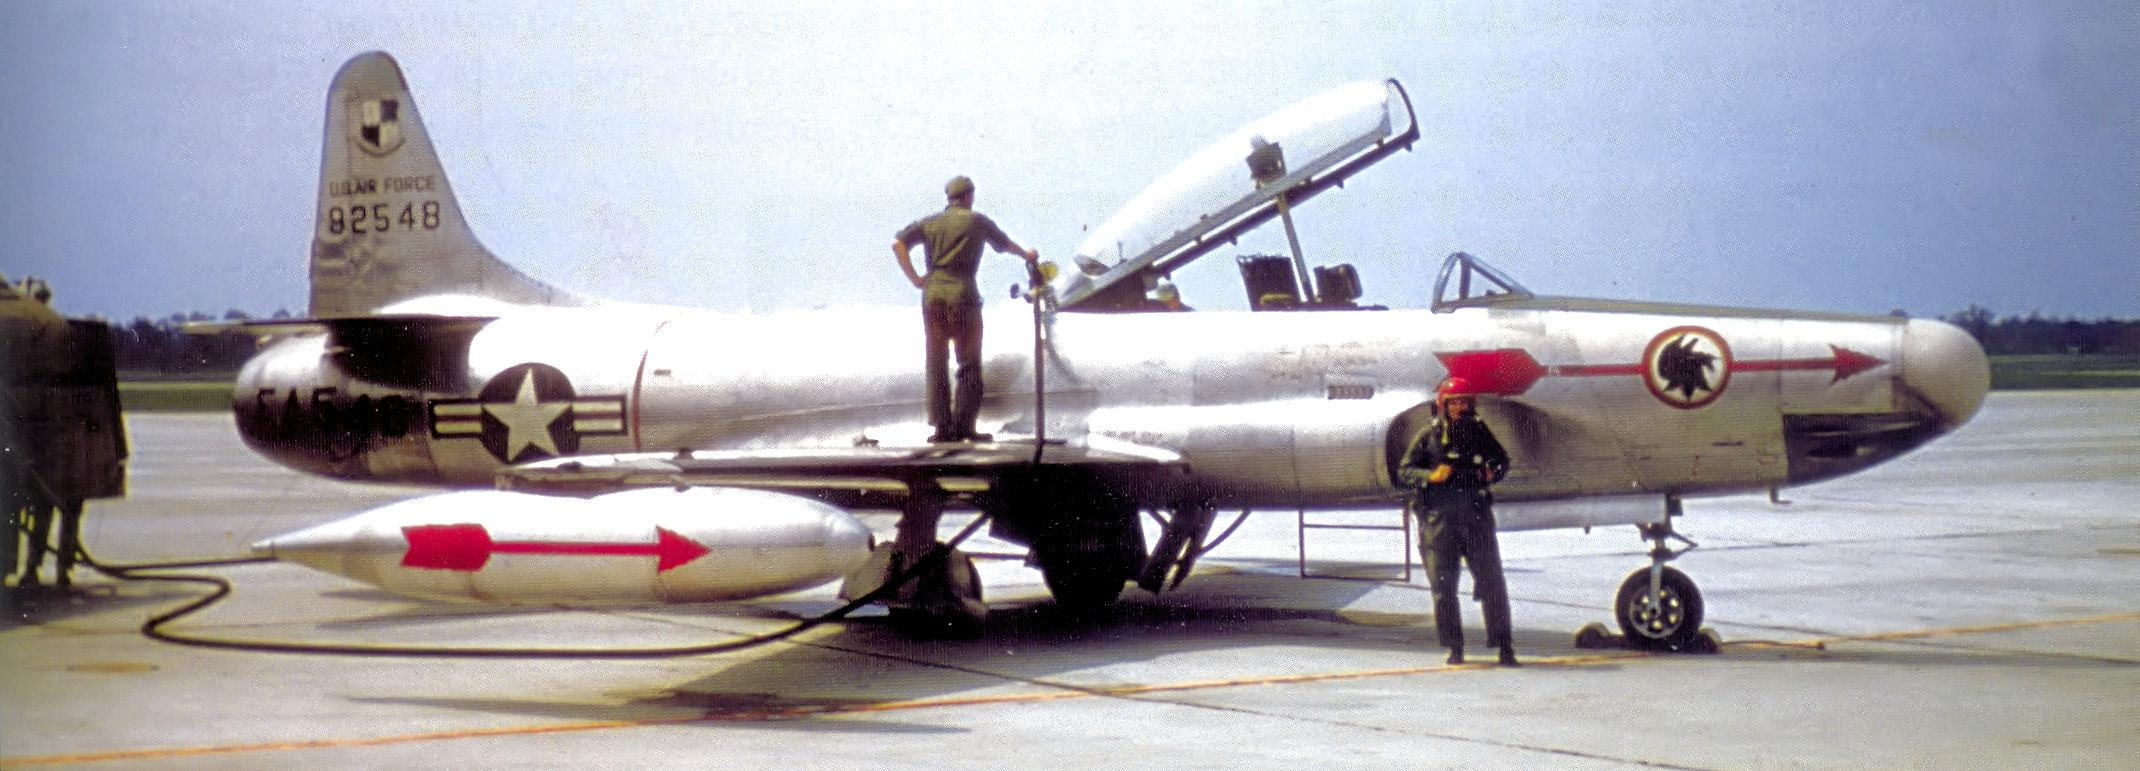

In [79]:
# df_test.at[1,'image']
import base64

image_64_decode = base64.b64decode(df.at[150,'image']) 
image_result = open('deer_decode.jpg', 'wb') # create a writable image and write the decoding result
image_result.write(image_64_decode)
from IPython.display import Image as IImage
IImage(filename='deer_decode.jpg') 

In [80]:
df.at[150,'ofa_caption']

'The pilots stand in front of the aircraft that was involved in the crash'

In [81]:
def get_sim(u,v):
    emb1 = embedder.encode(u)
    v = ' '.join(v)
    emb2 = embedder.encode(v)
    
    return float(util.cos_sim(emb1, emb2)[0][0])

In [82]:
def simple_search(context, t):
    percentage = 0
    for w in t:
        if w in context:
            percentage = percentage + 1
    return float(percentage/len(t))

In [83]:
df['gt_cap_cov'] = df.apply(lambda x: simple_search(x.caption, list(topics[x.topic_id])), axis=1)
df['gt_con_cov'] = df.apply(lambda x: simple_search(x.context, list(topics[x.topic_id])), axis=1)
df['ofa_cap_cov'] = df.apply(lambda x: simple_search(x.ofa_caption, list(topics[x.topic_id])), axis=1)
df['gt_cap_sim'] = df.apply(lambda x: get_sim(x.caption, list(topics[x.topic_id])), axis=1)
df['gt_con_sim'] = df.apply(lambda x: get_sim(x.context, list(topics[x.topic_id])), axis=1)
df['ofa_cap_sim'] = df.apply(lambda x: get_sim(x.ofa_caption, list(topics[x.topic_id])), axis=1)
df['ofa_av_sim'] = df.apply(lambda x: get_sim(x.ofa_caption, ['aircraft']), axis=1)
df['gt_av_sim'] = df.apply(lambda x: get_sim(x.caption, ['aircraft']), axis=1)
# df['ofa_cap_top_sim'] = df.apply(lambda x: get_sim(x.ofa_caption, toopic_dict[x.topic_id]), axis=1)

In [84]:
df['gt_air_flag'] = df.apply(lambda x: flag_search_gt(x.tag, aircraft_list), axis=1)

In [85]:
df

,uniq_id,image_id,caption,context,topic_id,labels,image,topics,ofa_caption,tag,gt_coverage,gt_cap_cov,gt_con_cov,ofa_cap_cov,gt_cap_sim,gt_con_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim,gt_air_flag
0,12,12,This drone is an example of UAV that could be ...,Humanrobot interaction is the study of interac...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A drone is a drone that can be flown in the air,"{'drone': 1, 'reconnaissance': 0, 'dji': 1, 'u...",0.8,0.4,0.0,0.1,0.525315,0.173796,0.553136,0.471068,0.330796,1.0
1,25,25,Ryan BQM34 Firebee jetpropelled drone used as ...,A target drone is an unmanned aerial vehicle g...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A airplane that was involved in the accident,"{'drone': 1, 'reconnaissance': 0, 'dji': 0, 'u...",0.7,0.1,0.4,0.0,0.525170,0.537072,0.158750,0.681749,0.458054,1.0
2,28,28,ARDrone preproduction prototype Parrot ARDrone...,Parrot ARDrone is a discontinued remote contro...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A helicopter in the process of taking off from...,"{'aerial': 1, 'aircraft': 1, 'sensor': 0, 'uav...",0.8,0.0,0.2,0.0,0.310604,0.380608,0.325291,0.524929,0.419030,1.0
3,63,63,English Naval Aircraft Factory TDN1 assault d...,The Naval Aircraft Factory TDN was an early un...,31,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,a,A aircraft in flight at the time of the accident,"{'aerial': 1, 'aircraft': 1, 'sensor': 0, 'uav...",0.2,0.1,0.3,0.1,0.476908,0.393437,0.218851,0.654898,0.484581,1.0
4,76,76,Unmanned Aerial Vehicle trainer at Holloman Ai...,The 429th Attack Squadron is a classic associa...,31,,iVBORw0KGgoAAAANSUhEUgAABAAAAAKpCAIAAACtvMnIAA...,a,A pilots sit in the cockpit of a flight simulator,"{'aerial': 0, 'aircraft': 1, 'sensor': 1, 'uav...",0.2,0.1,0.1,0.0,0.459108,0.170064,0.199585,0.373764,0.322168,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,1312,1312,A Pakistan International Airlines Boeing 720 s...,In March 1981 AlZulfiqar led by Murtaza Bhutto...,220,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,i,A A380 of the british international airlines i...,"{'airline': 1, 'aircraft': 1, 'tower': 0, 'hij...",0.3,0.2,0.4,0.1,0.579742,0.306740,0.436822,0.551860,0.481335,1.0
269,1321,1321,A photo of the monument shortly before it open...,The Pentagon Memorial located just southwest o...,220,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,i,A building of the united states supreme court,"{'airline': 0, 'aircraft': 0, 'tower': 0, 'hij...",0.0,0.1,0.0,0.0,0.565026,0.552611,0.253533,0.178205,0.216927,0.0
270,1339,1339,English Satam Muhammed Abdel Rahman alSuqami ...,Satam Muhammed Abdel Rahman alSuqami was a Sau...,220,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,i,a man was arrested on suspicion ofangeringange...,"{'airline': 0, 'aircraft': 1, 'tower': 0, 'hij...",0.1,0.2,0.4,0.0,0.608979,0.549664,0.002825,0.042065,0.384084,1.0
271,1368,1368,Overview of the accident site Empire Airlines ...,Empire Airlines Flight 8284 was a cargo flight...,220,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,i,The runway at the airport,"{'airline': 1, 'aircraft': 0, 'tower': 0, 'hij...",0.1,0.0,0.2,0.0,0.565329,0.334508,0.240142,0.413846,0.359052,0.0


In [86]:
av_groups = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k']
pg_dict = dict()


In [87]:
df[df['topics'] == 'k']

,uniq_id,image_id,caption,context,topic_id,labels,image,topics,ofa_caption,tag,gt_coverage,gt_cap_cov,gt_con_cov,ofa_cap_cov,gt_cap_sim,gt_con_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim,gt_air_flag
208,953,953,The pilot Wing Commander later Marshal of the...,The Chief of the Air Staff is the professional...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,a black and white photo of a man in uniform,"{'squadron': 0, 'aircraft': 0, 'fighter': 0, '...",0.333333,0.222222,0.000000,0.000000,0.581088,0.250486,0.136982,0.136710,0.387345,0.0
209,955,955,Pioneer aviator Charles Lindbergh at Loyola Pa...,St Johns College has three divisions and a num...,3,,iVBORw0KGgoAAAANSUhEUgAABBMAAAMtCAIAAABCc65ZAA...,k,a crowd of people standing on the deck of a ship,"{'squadron': 0, 'aircraft': 0, 'fighter': 0, '...",0.222222,0.000000,0.000000,0.000000,0.631478,0.035509,0.162965,0.118152,0.294549,0.0
210,959,959,75th FighterInterceptor Squadron North America...,The 75th Fighter Squadron is a United States A...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,two fighter jets flying in formation,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.888889,0.111111,0.444444,0.222222,0.622364,0.483826,0.566721,0.459212,0.421364,1.0
211,976,976,RAAF pilots mainly from No 76 Squadron at Miln...,No 76 Squadron is a Royal Australian Air Force...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,a group of men standing in front of a tent,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.555556,0.111111,0.777778,0.000000,0.568084,0.517609,0.068199,0.151687,0.305703,1.0
212,982,982,A US Marine Corps Douglas F3D2 Skyknight figh...,Marine Fighter Attack Squadron 531 was a Unite...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,two of the aircraft involved in the crash were...,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.555556,0.222222,0.222222,0.111111,0.615353,0.508660,0.273635,0.417136,0.504687,1.0
213,1019,1019,Capt Matt Bruckner an F15 Eagle pilot assigne...,The McDonnell Douglas F15 Eagle is an American...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,a fighter jet flying in the sky,"{'squadron': 0, 'aircraft': 1, 'fighter': 1, '...",0.777778,0.222222,0.333333,0.222222,0.589338,0.473909,0.638233,0.600265,0.438297,1.0
214,1024,1024,Fowler with the Wright Model B Flyer called th...,Robert George Fowler was an early aviation pio...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,a black and white photo of a man in a military...,"{'squadron': 0, 'aircraft': 1, 'fighter': 1, '...",0.444444,0.111111,0.222222,0.000000,0.501224,0.421774,0.198497,0.187629,0.398130,1.0
215,1051,1051,A fighter aircraft and three bombers 1 fighter...,A Military aircraft is an aeroplane made for m...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,four airplanes flying in formation in the sky,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.888889,0.222222,0.111111,0.111111,0.581474,0.439436,0.472523,0.576288,0.515840,1.0
216,1057,1057,The Douglas Boston English American Aircraft i...,James Ernest PellyFry DSO was an officer in th...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,A airplane flying in the air,"{'squadron': 0, 'aircraft': 1, 'fighter': 1, '...",0.777778,0.111111,0.777778,0.111111,0.585776,0.341889,0.566758,0.758952,0.535333,1.0
217,1065,1065,English 118 Sqn RCAF pilots at Sea Island BC ...,438 City of Montreal Tactical Helicopter Squad...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,The pilots pose for a picture in front of the ...,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.888889,0.111111,0.666667,0.222222,0.560586,0.403448,0.436589,0.451542,0.458099,1.0


In [88]:
for el in av_groups:
    pg_dict[el] = df[df['topics'] == el]
    pg_dict[el] = pg_dict[el].reset_index(drop=True)

In [89]:
pg_dict[el]

,uniq_id,image_id,caption,context,topic_id,labels,image,topics,ofa_caption,tag,gt_coverage,gt_cap_cov,gt_con_cov,ofa_cap_cov,gt_cap_sim,gt_con_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim,gt_air_flag
0,953,953,The pilot Wing Commander later Marshal of the...,The Chief of the Air Staff is the professional...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,a black and white photo of a man in uniform,"{'squadron': 0, 'aircraft': 0, 'fighter': 0, '...",0.333333,0.222222,0.000000,0.000000,0.581088,0.250486,0.136982,0.136710,0.387345,0.0
1,955,955,Pioneer aviator Charles Lindbergh at Loyola Pa...,St Johns College has three divisions and a num...,3,,iVBORw0KGgoAAAANSUhEUgAABBMAAAMtCAIAAABCc65ZAA...,k,a crowd of people standing on the deck of a ship,"{'squadron': 0, 'aircraft': 0, 'fighter': 0, '...",0.222222,0.000000,0.000000,0.000000,0.631478,0.035509,0.162965,0.118152,0.294549,0.0
2,959,959,75th FighterInterceptor Squadron North America...,The 75th Fighter Squadron is a United States A...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,two fighter jets flying in formation,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.888889,0.111111,0.444444,0.222222,0.622364,0.483826,0.566721,0.459212,0.421364,1.0
3,976,976,RAAF pilots mainly from No 76 Squadron at Miln...,No 76 Squadron is a Royal Australian Air Force...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,a group of men standing in front of a tent,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.555556,0.111111,0.777778,0.000000,0.568084,0.517609,0.068199,0.151687,0.305703,1.0
4,982,982,A US Marine Corps Douglas F3D2 Skyknight figh...,Marine Fighter Attack Squadron 531 was a Unite...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,two of the aircraft involved in the crash were...,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.555556,0.222222,0.222222,0.111111,0.615353,0.508660,0.273635,0.417136,0.504687,1.0
5,1019,1019,Capt Matt Bruckner an F15 Eagle pilot assigne...,The McDonnell Douglas F15 Eagle is an American...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,a fighter jet flying in the sky,"{'squadron': 0, 'aircraft': 1, 'fighter': 1, '...",0.777778,0.222222,0.333333,0.222222,0.589338,0.473909,0.638233,0.600265,0.438297,1.0
6,1024,1024,Fowler with the Wright Model B Flyer called th...,Robert George Fowler was an early aviation pio...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,a black and white photo of a man in a military...,"{'squadron': 0, 'aircraft': 1, 'fighter': 1, '...",0.444444,0.111111,0.222222,0.000000,0.501224,0.421774,0.198497,0.187629,0.398130,1.0
7,1051,1051,A fighter aircraft and three bombers 1 fighter...,A Military aircraft is an aeroplane made for m...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,four airplanes flying in formation in the sky,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.888889,0.222222,0.111111,0.111111,0.581474,0.439436,0.472523,0.576288,0.515840,1.0
8,1057,1057,The Douglas Boston English American Aircraft i...,James Ernest PellyFry DSO was an officer in th...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,A airplane flying in the air,"{'squadron': 0, 'aircraft': 1, 'fighter': 1, '...",0.777778,0.111111,0.777778,0.111111,0.585776,0.341889,0.566758,0.758952,0.535333,1.0
9,1065,1065,English 118 Sqn RCAF pilots at Sea Island BC ...,438 City of Montreal Tactical Helicopter Squad...,3,,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,k,The pilots pose for a picture in front of the ...,"{'squadron': 1, 'aircraft': 1, 'fighter': 1, '...",0.888889,0.111111,0.666667,0.222222,0.560586,0.403448,0.436589,0.451542,0.458099,1.0


In [90]:
pg_dict['a'].describe().round(2)

,uniq_id,image_id,topic_id,gt_coverage,gt_cap_cov,gt_con_cov,ofa_cap_cov,gt_cap_sim,gt_con_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim,gt_air_flag
count,7.00,7.00,7.0,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00,7.00
mean,62.00,62.00,31.0,0.49,0.16,0.19,0.06,0.46,0.32,0.31,0.49,0.38,0.86
std,42.57,42.57,0.0,0.31,0.14,0.16,0.05,0.07,0.18,0.13,0.17,0.08,0.38
min,12.00,12.00,31.0,0.10,0.00,0.00,0.00,0.31,0.09,0.16,0.20,0.27,0.00
25%,26.50,26.50,31.0,0.20,0.10,0.05,0.00,0.45,0.17,0.21,0.42,0.33,1.00
50%,63.00,63.00,31.0,0.60,0.10,0.20,0.10,0.46,0.38,0.33,0.52,0.34,1.00
75%,93.50,93.50,31.0,0.75,0.20,0.30,0.10,0.50,0.46,0.35,0.59,0.44,1.00
max,119.00,119.00,31.0,0.80,0.40,0.40,0.10,0.53,0.54,0.55,0.68,0.48,1.00


In [91]:
# gt_coverage
df[['gt_air_flag', 'gt_coverage', 'ofa_cap_cov', 'gt_cap_sim', 'ofa_cap_sim', 'ofa_av_sim', 'gt_av_sim']].describe().round(2)

,gt_air_flag,gt_coverage,ofa_cap_cov,gt_cap_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim
count,273.00,273.00,273.00,273.00,273.00,273.00,273.00
mean,0.78,0.42,0.09,0.53,0.34,0.45,0.38
std,0.41,0.24,0.09,0.08,0.15,0.16,0.09
min,0.00,0.00,0.00,0.31,-0.06,0.02,0.10
25%,1.00,0.22,0.00,0.48,0.26,0.36,0.31
50%,1.00,0.40,0.10,0.54,0.35,0.48,0.38
75%,1.00,0.60,0.12,0.59,0.45,0.56,0.44
max,1.00,1.00,0.40,0.77,0.70,0.79,0.71


In [92]:
for el in pg_dict:
    print(el)
    display(pg_dict[el][['gt_air_flag', 'gt_coverage', 'ofa_cap_cov', 'gt_cap_sim', 'ofa_cap_sim', 'ofa_av_sim', 'gt_av_sim']].describe().round(2))

a


,gt_air_flag,gt_coverage,ofa_cap_cov,gt_cap_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim
count,7.00,7.00,7.00,7.00,7.00,7.00,7.00
mean,0.86,0.49,0.06,0.46,0.31,0.49,0.38
std,0.38,0.31,0.05,0.07,0.13,0.17,0.08
min,0.00,0.10,0.00,0.31,0.16,0.20,0.27
25%,1.00,0.20,0.00,0.45,0.21,0.42,0.33
50%,1.00,0.60,0.10,0.46,0.33,0.52,0.34
75%,1.00,0.75,0.10,0.50,0.35,0.59,0.44
max,1.00,0.80,0.10,0.53,0.55,0.68,0.48


b


,gt_air_flag,gt_coverage,ofa_cap_cov,gt_cap_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim
count,13.00,13.00,13.00,13.00,13.00,13.00,13.00
mean,0.38,0.45,0.10,0.56,0.41,0.38,0.35
std,0.51,0.21,0.09,0.03,0.17,0.20,0.06
min,0.00,0.14,0.00,0.50,-0.00,0.05,0.24
25%,0.00,0.43,0.00,0.54,0.31,0.22,0.31
50%,0.00,0.43,0.14,0.55,0.39,0.36,0.34
75%,1.00,0.43,0.14,0.58,0.51,0.54,0.40
max,1.00,0.86,0.29,0.63,0.64,0.71,0.46


c


...

,gt_air_flag,gt_coverage,ofa_cap_cov,gt_cap_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim
count,47.00,47.00,47.00,47.00,47.00,47.00,47.00
mean,0.83,0.47,0.11,0.56,0.36,0.46,0.36
std,0.38,0.19,0.08,0.07,0.14,0.13,0.09
min,0.00,0.10,0.00,0.40,0.08,0.12,0.18
25%,1.00,0.30,0.05,0.52,0.27,0.40,0.28
50%,1.00,0.44,0.10,0.58,0.36,0.49,0.36
75%,1.00,0.60,0.17,0.61,0.45,0.55,0.44
max,1.00,0.88,0.29,0.72,0.69,0.66,0.58


i


,gt_air_flag,gt_coverage,ofa_cap_cov,gt_cap_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim
count,46.00,46.00,46.00,46.00,46.00,46.00,46.00
mean,0.72,0.36,0.07,0.52,0.35,0.38,0.35
std,0.46,0.26,0.09,0.07,0.18,0.16,0.09
min,0.00,0.00,0.00,0.33,0.00,0.02,0.10
25%,0.00,0.12,0.00,0.48,0.22,0.24,0.30
50%,1.00,0.38,0.05,0.52,0.38,0.42,0.35
75%,1.00,0.60,0.12,0.57,0.49,0.49,0.40
max,1.00,0.88,0.40,0.63,0.70,0.69,0.58


k


,gt_air_flag,gt_coverage,ofa_cap_cov,gt_cap_sim,ofa_cap_sim,ofa_av_sim,gt_av_sim
count,19.00,19.00,19.00,19.00,19.00,19.00,19.00
mean,0.58,0.45,0.07,0.51,0.30,0.36,0.40
std,0.51,0.30,0.09,0.08,0.20,0.20,0.09
min,0.00,0.00,0.00,0.42,-0.03,0.11,0.27
25%,0.00,0.22,0.00,0.44,0.15,0.17,0.31
50%,1.00,0.44,0.00,0.50,0.27,0.42,0.42
75%,1.00,0.67,0.11,0.58,0.45,0.51,0.46
max,1.00,0.89,0.22,0.63,0.64,0.76,0.54


In [93]:
for el in pg_dict:
    print(el)
    display(pg_dict[el][['gt_cap_sim', 'gt_coverage']].describe().round(2))

a


,gt_cap_sim,gt_coverage
count,7.00,7.00
mean,0.46,0.49
std,0.07,0.31
min,0.31,0.10
25%,0.45,0.20
50%,0.46,0.60
75%,0.50,0.75
max,0.53,0.80


b


,gt_cap_sim,gt_coverage
count,13.00,13.00
mean,0.56,0.45
std,0.03,0.21
min,0.50,0.14
25%,0.54,0.43
50%,0.55,0.43
75%,0.58,0.43
max,0.63,0.86


c


...

,gt_cap_sim,gt_coverage
count,47.00,47.00
mean,0.56,0.47
std,0.07,0.19
min,0.40,0.10
25%,0.52,0.30
50%,0.58,0.44
75%,0.61,0.60
max,0.72,0.88


i


,gt_cap_sim,gt_coverage
count,46.00,46.00
mean,0.52,0.36
std,0.07,0.26
min,0.33,0.00
25%,0.48,0.12
50%,0.52,0.38
75%,0.57,0.60
max,0.63,0.88


k


,gt_cap_sim,gt_coverage
count,19.00,19.00
mean,0.51,0.45
std,0.08,0.30
min,0.42,0.00
25%,0.44,0.22
50%,0.50,0.44
75%,0.58,0.67
max,0.63,0.89


In [94]:
for el in pg_dict:
    print(el)
    display(pg_dict[el][['ofa_av_sim', 'ofa_cap_sim']].describe().round(2))

a


,ofa_av_sim,ofa_cap_sim
count,7.00,7.00
mean,0.49,0.31
std,0.17,0.13
min,0.20,0.16
25%,0.42,0.21
50%,0.52,0.33
75%,0.59,0.35
max,0.68,0.55


b


,ofa_av_sim,ofa_cap_sim
count,13.00,13.00
mean,0.38,0.41
std,0.20,0.17
min,0.05,-0.00
25%,0.22,0.31
50%,0.36,0.39
75%,0.54,0.51
max,0.71,0.64


c


...

,ofa_av_sim,ofa_cap_sim
count,47.00,47.00
mean,0.46,0.36
std,0.13,0.14
min,0.12,0.08
25%,0.40,0.27
50%,0.49,0.36
75%,0.55,0.45
max,0.66,0.69


i


,ofa_av_sim,ofa_cap_sim
count,46.00,46.00
mean,0.38,0.35
std,0.16,0.18
min,0.02,0.00
25%,0.24,0.22
50%,0.42,0.38
75%,0.49,0.49
max,0.69,0.70


k


,ofa_av_sim,ofa_cap_sim
count,19.00,19.00
mean,0.36,0.30
std,0.20,0.20
min,0.11,-0.03
25%,0.17,0.15
50%,0.42,0.27
75%,0.51,0.45
max,0.76,0.64


In [95]:
for el in pg_dict:
    print(el)
    display(pg_dict[el][['gt_air_flag']].describe().round(2))

a


,gt_air_flag
count,7.00
mean,0.86
std,0.38
min,0.00
25%,1.00
50%,1.00
75%,1.00
max,1.00


b


,gt_air_flag
count,13.00
mean,0.38
std,0.51
min,0.00
25%,0.00
50%,0.00
75%,1.00
max,1.00


c


...

,gt_air_flag
count,47.00
mean,0.83
std,0.38
min,0.00
25%,1.00
50%,1.00
75%,1.00
max,1.00


i


,gt_air_flag
count,46.00
mean,0.72
std,0.46
min,0.00
25%,0.00
50%,1.00
75%,1.00
max,1.00


k


,gt_air_flag
count,19.00
mean,0.58
std,0.51
min,0.00
25%,0.00
50%,1.00
75%,1.00
max,1.00


In [96]:
# gt_coverage
df[['ofa_av_sim', 'ofa_cap_sim', 'gt_air_flag']].describe().round(2)

,ofa_av_sim,ofa_cap_sim,gt_air_flag
count,273.00,273.00,273.00
mean,0.45,0.34,0.78
std,0.16,0.15,0.41
min,0.02,-0.06,0.00
25%,0.36,0.26,1.00
50%,0.48,0.35,1.00
75%,0.56,0.45,1.00
max,0.79,0.70,1.00


In [ ]:
df.to_pickle('/raid/AISSEL/Hamed/datasets/av_data/df_test.pk')